In [29]:
import pandas as pd
import numpy as np

# 1. Load input datasets
city_df = pd.read_excel("merged_city_dealers_all_columns_exact.xlsx")
state_df = pd.read_excel("state_level_results_reduced.xlsx")

# 2. Validate state name consistency before merging
print("Number of unique states in city dataset:", city_df["state_full"].nunique())
print("Number of unique states in state dataset:", state_df["State"].nunique())

# 3. Merge state-level data into city-level dataset
model_df = city_df.merge(
    state_df,
    left_on="state_full",
    right_on="State",
    how="left"
)

# 4. Check for unmatched states after merge
unmatched_states = model_df.loc[
    model_df["cluster_reduced"].isna(), "state_full"
].dropna().unique()

print("Unmatched states after merge:", unmatched_states)

# 5. Create Stage 1 target variable (dealer presence)
model_df["has_dealer"] = (model_df["dealer_count"] > 0).astype(int)

# 6. Basic feature transformations
model_df["log_population"] = np.log1p(model_df["population"])
model_df["log_density"] = np.log1p(model_df["density"])

# Convert boolean variables to binary (0/1)
model_df["military"] = model_df["military"].astype(int)
model_df["incorporated"] = model_df["incorporated"].astype(int)

# 7. Save processed modeling table
model_df.to_excel("city_state_model_table.xlsx", index=False)
model_df.to_csv("city_state_model_table.csv", index=False)

print("Main modeling table saved: city_state_model_table.xlsx / city_state_model_table.csv")
print(model_df.shape)
print(model_df.head())

Number of unique states in city dataset: 52
Number of unique states in state dataset: 51
Unmatched states after merge: ['Puerto Rico']
Main modeling table saved: city_state_model_table.xlsx / city_state_model_table.csv
(31257, 51)
     city_name  state_full state_abbr_x  dealer_count   city_ascii  \
0     New York    New York           NY             1     New York   
1  Los Angeles  California           CA             2  Los Angeles   
2      Chicago    Illinois           IL             4      Chicago   
3        Miami     Florida           FL             3        Miami   
4      Houston       Texas           TX             6      Houston   

   county_fips  county_name      lat       lng  population  ...  \
0        36081       Queens  40.6943  -73.9249    19268388  ...   
1         6037  Los Angeles  34.1141 -118.4068    11984083  ...   
2        17031         Cook  41.8375  -87.6866     8609571  ...   
3        12086   Miami-Dade  25.7840  -80.2101     6391670  ...   
4        4820

In [30]:
print(model_df["has_dealer"].value_counts(dropna=False))
print(model_df["has_dealer"].mean())

print(
    model_df.groupby("cluster_reduced")["has_dealer"]
    .agg(["mean", "count"])
    .sort_index()
)

print(
    model_df.groupby("expansion_priority_band")["has_dealer"]
    .agg(["mean", "count"])
)

has_dealer
0    30220
1     1037
Name: count, dtype: int64
0.033176568448667496
                     mean  count
cluster_reduced                 
0.0              0.026055  16580
1.0              0.044662  12270
2.0              0.000000      1
3.0              0.063584    173
4.0              0.023566   1952
                             mean  count
expansion_priority_band                 
High                     0.056800   3169
Low                      0.041427   3476
Medium                   0.039822   5625
Non-target               0.026141  18706


In [31]:
print(model_df.isna().sum().sort_values(ascending=False).head(20))

EV Charging Port             281
EV Charging Station          281
URBAN POP_PCT                281
Population Density           281
Population                   281
Mean households income       281
Registration Count           281
state_priority_score         281
growth_potential_score       281
pressure_score               281
supply_score                 281
demand_score                 281
expansion_priority_band      281
target_cluster_flag          281
cluster_role                 281
market_type                  281
cluster_reduced              281
state_abbr_y                 281
State                        281
registrations_per_station    281
dtype: int64


In [32]:
print(model_df.loc[model_df["cluster_reduced"].isna(), "state_full"].value_counts())

state_full
Puerto Rico    281
Name: count, dtype: int64


In [33]:
model_df = model_df[model_df["state_full"] != "Puerto Rico"].copy()

In [34]:
print(model_df.shape)
print(model_df.isna().sum().sort_values(ascending=False).head(20))

(30976, 51)
zips            2
state_full      0
city_name       0
state_abbr_x    0
dealer_count    0
county_fips     0
city_ascii      0
lat             0
lng             0
population      0
county_name     0
density         0
source          0
incorporated    0
military        0
timezone        0
ranking         0
id              0
state_match     0
State           0
dtype: int64


In [35]:
df_stage1 = model_df.copy()
df_stage1 = df_stage1.drop(columns=["state_match"], errors="ignore")

features_stage1 = [
    "log_population",
    "log_density",
    "military",
    "incorporated",
    "cluster_reduced",
    "demand_score",
    "supply_score",
    "pressure_score",
    "growth_potential_score",
    "state_priority_score"
]

numeric_features = [
    "log_population",
    "log_density",
    "demand_score",
    "supply_score",
    "pressure_score",
    "growth_potential_score",
    "state_priority_score"
]

categorical_features = [
    "military",
    "incorporated",
    "cluster_reduced"
]

In [36]:
print("Number of duplicate city rows:", df_stage1.duplicated(subset=["city_name", "state_full"]).sum())

print(
    df_stage1.groupby(["city_name", "state_full"]).size()
    .sort_values(ascending=False)
    .head(20)
)

Number of duplicate city rows: 67
city_name       state_full  
Chula Vista     Texas           3
Georgetown      Pennsylvania    3
Midway          Florida         3
Oakland         Pennsylvania    3
Oakwood         Ohio            3
Unionville      Pennsylvania    3
Kingston        Illinois        2
Fairview        Oregon          2
Harrisburg      Ohio            2
Jamestown       Pennsylvania    2
Jefferson       Pennsylvania    2
Fredericksburg  Pennsylvania    2
Halls           Tennessee       2
Geneva          Indiana         2
Beavertown      Pennsylvania    2
Clinton         Pennsylvania    2
La Cueva        New Mexico      2
Bull Run        Virginia        2
Clear Lake      South Dakota    2
Lakewood        Illinois        2
dtype: int64


Dataset shape: (30976, 52)
Positive class ratio: 0.033478
Number of city groups: 30909

1. Univariate diagnostics

===== log_population =====
              count       mean       std       min       25%        50%  \
has_dealer                                                                
0           29939.0   6.755851  2.011196  0.000000  5.547127   6.760415   
1            1037.0  10.848329  1.541851  5.583496  9.795345  10.743221   

                  75%        max  
has_dealer                        
0            8.073715  15.469993  
1           11.772771  16.773976  

===== log_density =====
              count      mean       std       min       25%       50%  \
has_dealer                                                              
0           29939.0  5.257950  1.445855  0.000000  4.438525  5.442418   
1            1037.0  6.716451  0.754311  1.722767  6.256901  6.718530   

                 75%        max  
has_dealer                       
0           6.229201  10.263080

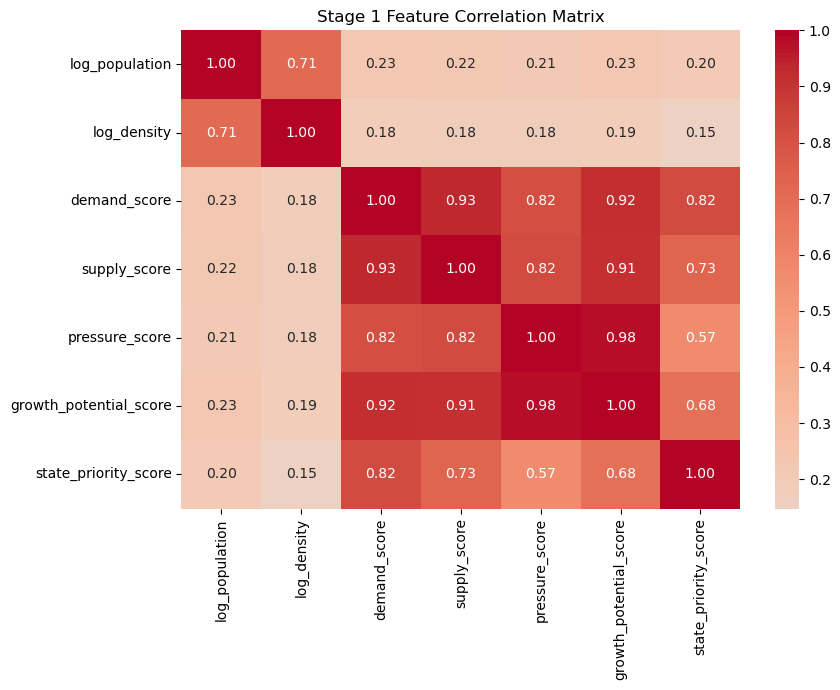

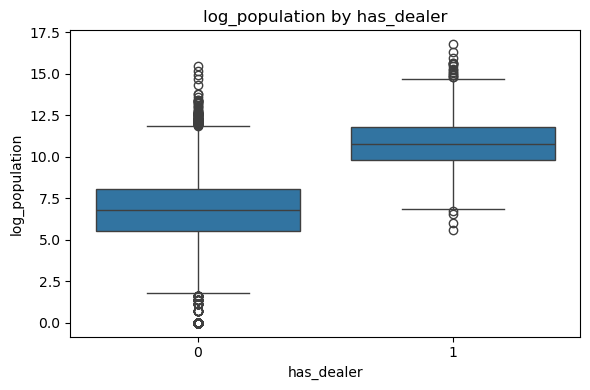

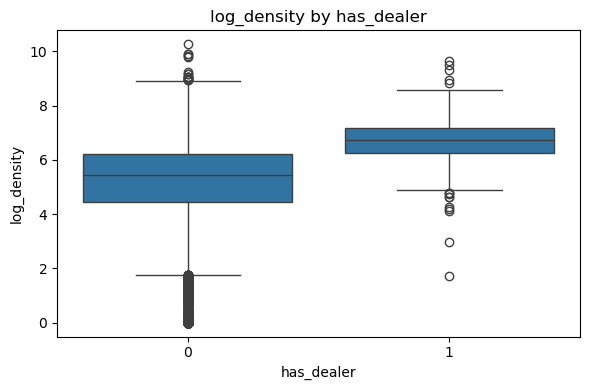

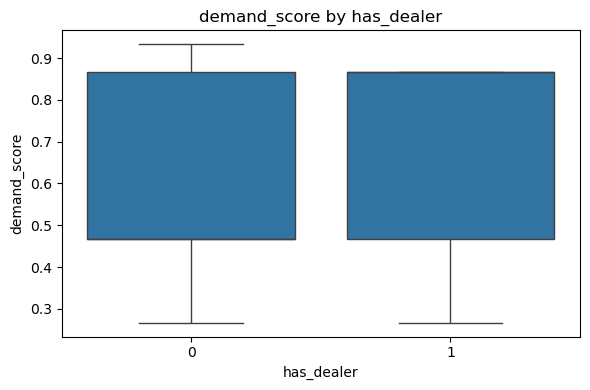

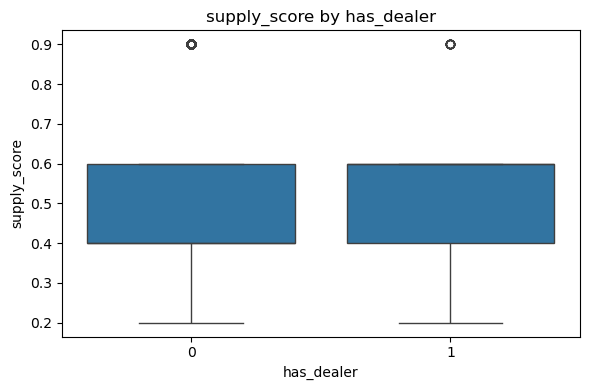

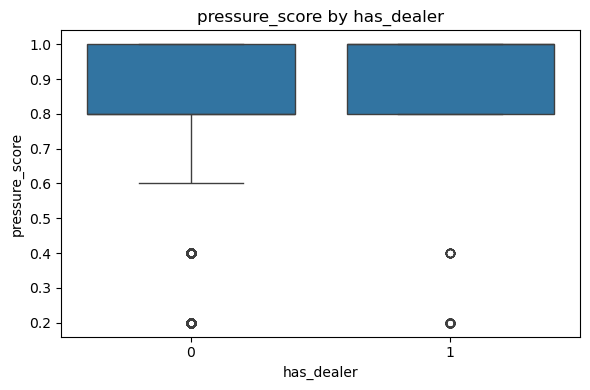

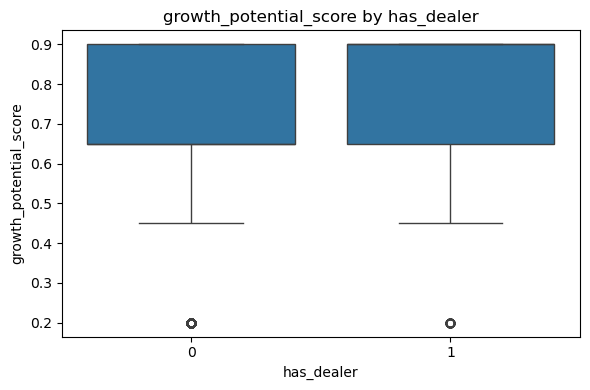

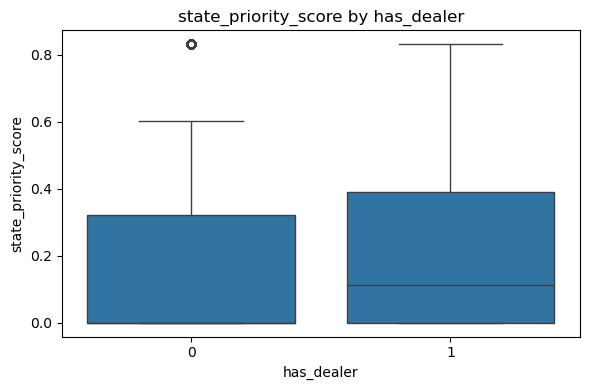


3. Dataset split summary
Train: (18585, 52) Positive class ratio: 0.034544
Val  : (6194, 52) Positive class ratio: 0.033097
Test : (6197, 52) Positive class ratio: 0.03066

Group overlap check:
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0

Running V1_city_only
Final threshold: 0.78
Threshold rule: precision-max under recall>=0.75
Validation ROC-AUC: 0.9572
Validation PR-AUC : 0.4962
Test ROC-AUC      : 0.9529
Test PR-AUC       : 0.5346
Test Precision    : 0.3079
Test Recall       : 0.7632
Test F1           : 0.4387

Test classification report:
              precision    recall  f1-score   support

           0     0.9921    0.9457    0.9684      6007
           1     0.3079    0.7632    0.4387       190

    accuracy                         0.9401      6197
   macro avg     0.6500    0.8544    0.7036      6197
weighted avg     0.9712    0.9401    0.9521      6197

Confusion matrix:
[[5681  326]
 [  45  145]]

Running V2_city_plus_cluster
Final threshold: 0.77
Threshold rule: precis

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# 0. Data preparation
# =========================================================
df_stage1 = model_df.copy()

# Remove Puerto Rico again as a precaution
df_stage1 = df_stage1[df_stage1["state_full"] != "Puerto Rico"].copy()

# Create a group key to prevent the same city from appearing across train / val / test
df_stage1["city_state_group"] = (
    df_stage1["city_name"].astype(str).str.strip() + " | " +
    df_stage1["state_full"].astype(str).str.strip()
)

target = "has_dealer"

print("Dataset shape:", df_stage1.shape)
print("Positive class ratio:", round(df_stage1[target].mean(), 6))
print("Number of city groups:", df_stage1["city_state_group"].nunique())


# =========================================================
# 1. Stage 1 feature diagnostics
# =========================================================

# ---------- 1.1 Define candidate features ----------
feature_check_cols = [
    "log_population",
    "log_density",
    "military",
    "incorporated",
    "cluster_reduced",
    "demand_score",
    "supply_score",
    "pressure_score",
    "growth_potential_score",
    "state_priority_score"
]

print("\n==============================")
print("1. Univariate diagnostics")
print("==============================")

for col in feature_check_cols:
    print(f"\n===== {col} =====")

    # Numerical features
    if pd.api.types.is_numeric_dtype(df_stage1[col]):
        print(df_stage1.groupby(target)[col].describe())
    else:
        print(pd.crosstab(df_stage1[col], df_stage1[target], normalize="index"))


# ---------- 1.2 Correlation matrix ----------
corr_cols = [
    "log_population",
    "log_density",
    "demand_score",
    "supply_score",
    "pressure_score",
    "growth_potential_score",
    "state_priority_score"
]

corr_matrix = df_stage1[corr_cols].corr()

print("\n==============================")
print("2. Correlation matrix for numeric features")
print("==============================")
print(corr_matrix.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Stage 1 Feature Correlation Matrix")
plt.tight_layout()
plt.show()


# ---------- 1.3 Simple distribution plots (optional) ----------
plot_cols = [
    "log_population",
    "log_density",
    "demand_score",
    "supply_score",
    "pressure_score",
    "growth_potential_score",
    "state_priority_score"
]

for col in plot_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_stage1, x=target, y=col)
    plt.title(f"{col} by has_dealer")
    plt.tight_layout()
    plt.show()


# =========================================================
# 2. Group-based train / validation / test split
# =========================================================
all_features_for_split = list(set(feature_check_cols))

X_all = df_stage1[all_features_for_split]
y_all = df_stage1[target]
groups_all = df_stage1["city_state_group"]

# First split out test = 20%
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_all, y_all, groups=groups_all))

df_train_val = df_stage1.iloc[train_val_idx].copy()
df_test = df_stage1.iloc[test_idx].copy()

# Then split validation = 25% of train_val = 20% overall
X_train_val = df_train_val[all_features_for_split]
y_train_val = df_train_val[target]
groups_train_val = df_train_val["city_state_group"]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(gss_val.split(X_train_val, y_train_val, groups=groups_train_val))

df_train = df_train_val.iloc[train_idx_rel].copy()
df_val = df_train_val.iloc[val_idx_rel].copy()

print("\n==============================")
print("3. Dataset split summary")
print("==============================")
print("Train:", df_train.shape, "Positive class ratio:", round(df_train[target].mean(), 6))
print("Val  :", df_val.shape, "Positive class ratio:", round(df_val[target].mean(), 6))
print("Test :", df_test.shape, "Positive class ratio:", round(df_test[target].mean(), 6))

train_groups = set(df_train["city_state_group"])
val_groups = set(df_val["city_state_group"])
test_groups = set(df_test["city_state_group"])

print("\nGroup overlap check:")
print("train ∩ val :", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("val   ∩ test:", len(val_groups & test_groups))


# =========================================================
# 3. Define three feature set versions
# =========================================================
feature_versions = {
    "V1_city_only": {
        "features": [
            "log_population",
            "log_density",
            "military",
            "incorporated"
        ],
        "numeric": [
            "log_population",
            "log_density"
        ],
        "categorical": [
            "military",
            "incorporated"
        ]
    },

    "V2_city_plus_cluster": {
        "features": [
            "log_population",
            "log_density",
            "military",
            "incorporated",
            "cluster_reduced"
        ],
        "numeric": [
            "log_population",
            "log_density"
        ],
        "categorical": [
            "military",
            "incorporated",
            "cluster_reduced"
        ]
    },

    "V3_full": {
        "features": [
            "log_population",
            "log_density",
            "military",
            "incorporated",
            "cluster_reduced",
            "demand_score",
            "supply_score",
            "pressure_score",
            "growth_potential_score",
            "state_priority_score"
        ],
        "numeric": [
            "log_population",
            "log_density",
            "demand_score",
            "supply_score",
            "pressure_score",
            "growth_potential_score",
            "state_priority_score"
        ],
        "categorical": [
            "military",
            "incorporated",
            "cluster_reduced"
        ]
    }
}


# =========================================================
# 4. Define utility functions: threshold search and model evaluation
# =========================================================
def evaluate_thresholds(y_true, y_prob, thresholds):
    rows = []

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred)

        tn, fp, fn, tp = cm.ravel()

        rows.append({
            "threshold": t,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "tn": tn,
            "fp": fp,
            "fn": fn,
            "tp": tp,
            "predicted_positive": int(y_pred.sum())
        })

    return pd.DataFrame(rows)


def build_pipeline(numeric_features, categorical_features):
    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ])

    return clf


def choose_threshold_from_validation(y_val, val_prob, recall_floor=0.75):
    threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
    threshold_table = evaluate_thresholds(y_val, val_prob, threshold_grid)

    best_by_f1 = threshold_table.sort_values(
        by=["f1", "precision", "recall"],
        ascending=[False, False, False]
    ).iloc[0]

    valid_candidates = threshold_table[threshold_table["recall"] >= recall_floor].copy()

    if len(valid_candidates) > 0:
        best_by_recall_floor = valid_candidates.sort_values(
            by=["precision", "f1", "threshold"],
            ascending=[False, False, True]
        ).iloc[0]
        final_threshold = float(best_by_recall_floor["threshold"])
        rule = f"precision-max under recall>={recall_floor}"
    else:
        best_by_recall_floor = None
        final_threshold = float(best_by_f1["threshold"])
        rule = "max-f1"

    return threshold_table, best_by_f1, best_by_recall_floor, final_threshold, rule


def run_one_version(version_name, version_config, df_train, df_val, df_test, target, recall_floor=0.75):
    features = version_config["features"]
    numeric_features = version_config["numeric"]
    categorical_features = version_config["categorical"]

    X_train = df_train[features]
    y_train = df_train[target]

    X_val = df_val[features]
    y_val = df_val[target]

    X_test = df_test[features]
    y_test = df_test[target]

    clf = build_pipeline(numeric_features, categorical_features)
    clf.fit(X_train, y_train)

    val_prob = clf.predict_proba(X_val)[:, 1]
    test_prob = clf.predict_proba(X_test)[:, 1]

    threshold_table, best_by_f1, best_by_recall_floor, final_threshold, rule = choose_threshold_from_validation(
        y_val=y_val,
        val_prob=val_prob,
        recall_floor=recall_floor
    )

    test_pred = (test_prob >= final_threshold).astype(int)

    val_roc_auc = roc_auc_score(y_val, val_prob)
    val_pr_auc = average_precision_score(y_val, val_prob)

    test_roc_auc = roc_auc_score(y_test, test_prob)
    test_pr_auc = average_precision_score(y_test, test_prob)

    test_precision = precision_score(y_test, test_pred, zero_division=0)
    test_recall = recall_score(y_test, test_pred, zero_division=0)
    test_f1 = f1_score(y_test, test_pred, zero_division=0)

    result_summary = {
        "version": version_name,
        "n_features": len(features),
        "features": ", ".join(features),
        "threshold_rule": rule,
        "final_threshold": final_threshold,
        "val_roc_auc": val_roc_auc,
        "val_pr_auc": val_pr_auc,
        "test_roc_auc": test_roc_auc,
        "test_pr_auc": test_pr_auc,
        "test_precision": test_precision,
        "test_recall": test_recall,
        "test_f1": test_f1
    }

    detailed_outputs = {
        "model": clf,
        "threshold_table": threshold_table,
        "best_by_f1": best_by_f1,
        "best_by_recall_floor": best_by_recall_floor,
        "test_pred": test_pred,
        "test_prob": test_prob,
        "y_test": y_test,
        "X_test": X_test
    }

    return result_summary, detailed_outputs


# =========================================================
# 5. Run and compare the three model versions
# =========================================================
comparison_rows = []
all_outputs = {}

for version_name, version_config in feature_versions.items():
    print("\n" + "=" * 60)
    print(f"Running {version_name}")
    print("=" * 60)

    summary, outputs = run_one_version(
        version_name=version_name,
        version_config=version_config,
        df_train=df_train,
        df_val=df_val,
        df_test=df_test,
        target=target,
        recall_floor=0.75
    )

    comparison_rows.append(summary)
    all_outputs[version_name] = outputs

    print("Final threshold:", summary["final_threshold"])
    print("Threshold rule:", summary["threshold_rule"])
    print("Validation ROC-AUC:", round(summary["val_roc_auc"], 4))
    print("Validation PR-AUC :", round(summary["val_pr_auc"], 4))
    print("Test ROC-AUC      :", round(summary["test_roc_auc"], 4))
    print("Test PR-AUC       :", round(summary["test_pr_auc"], 4))
    print("Test Precision    :", round(summary["test_precision"], 4))
    print("Test Recall       :", round(summary["test_recall"], 4))
    print("Test F1           :", round(summary["test_f1"], 4))

    print("\nTest classification report:")
    print(classification_report(
        outputs["y_test"],
        outputs["test_pred"],
        digits=4
    ))

    print("Confusion matrix:")
    print(confusion_matrix(outputs["y_test"], outputs["test_pred"]))


comparison_df = pd.DataFrame(comparison_rows)

print("\n==============================")
print("4. Summary comparison across the three feature sets")
print("==============================")
print(
    comparison_df[
        [
            "version",
            "n_features",
            "final_threshold",
            "val_roc_auc",
            "val_pr_auc",
            "test_roc_auc",
            "test_pr_auc",
            "test_precision",
            "test_recall",
            "test_f1"
        ]
    ].sort_values("test_pr_auc", ascending=False)
)

comparison_df.to_excel("stage1_feature_version_comparison.xlsx", index=False)


# =========================================================
# 6. Export threshold search tables for each version
# =========================================================
for version_name, outputs in all_outputs.items():
    outputs["threshold_table"].to_excel(
        f"stage1_threshold_search_{version_name}.xlsx",
        index=False
    )

print("\nExported files:")
print("- stage1_feature_version_comparison.xlsx")
for version_name in all_outputs.keys():
    print(f"- stage1_threshold_search_{version_name}.xlsx")

In [38]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import PoissonRegressor

# =========================================================
# 0. Prepare Stage 2 data
#    Keep only cities with dealer_count > 0
# =========================================================
df_stage2 = model_df.copy()
df_stage2 = df_stage2[df_stage2["state_full"] != "Puerto Rico"].copy()
df_stage2 = df_stage2[df_stage2["dealer_count"] > 0].copy()

# Group by city to prevent the same city from appearing across train / val / test
df_stage2["city_state_group"] = (
    df_stage2["city_name"].astype(str).str.strip() + " | " +
    df_stage2["state_full"].astype(str).str.strip()
)

print("Stage 2 dataset shape:", df_stage2.shape)
print("Number of unique city groups:", df_stage2["city_state_group"].nunique())
print("\nDealer count distribution:")
print(df_stage2["dealer_count"].value_counts().sort_index())

# =========================================================
# 1. Stage 2 feature engineering: define three feature set versions
# =========================================================
feature_versions_stage2 = {
    "A_city_capacity": {
        "features": [
            "log_population",
            "log_density",
            "incorporated"
        ],
        "numeric": [
            "log_population",
            "log_density"
        ],
        "categorical": [
            "incorporated"
        ]
    },

    "B_plus_cluster": {
        "features": [
            "log_population",
            "log_density",
            "incorporated",
            "cluster_reduced"
        ],
        "numeric": [
            "log_population",
            "log_density"
        ],
        "categorical": [
            "incorporated",
            "cluster_reduced"
        ]
    },

    "C_plus_cluster_priority": {
        "features": [
            "log_population",
            "log_density",
            "incorporated",
            "cluster_reduced",
            "state_priority_score"
        ],
        "numeric": [
            "log_population",
            "log_density",
            "state_priority_score"
        ],
        "categorical": [
            "incorporated",
            "cluster_reduced"
        ]
    }
}

target = "dealer_count"

# Keep all columns that may be used across feature versions
all_stage2_feature_cols = sorted(
    list(
        set(
            sum(
                [cfg["features"] for cfg in feature_versions_stage2.values()],
                []
            )
        )
    )
)

required_cols = all_stage2_feature_cols + [
    target, "city_name", "state_full", "city_state_group"
]

df_stage2 = df_stage2[required_cols].copy()

# =========================================================
# 2. Group-based train / validation / test split
# =========================================================
X_all = df_stage2[all_stage2_feature_cols]
y_all = df_stage2[target]
groups_all = df_stage2["city_state_group"]

# First split out test = 20%
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_all, y_all, groups=groups_all))

df_train_val = df_stage2.iloc[train_val_idx].copy()
df_test = df_stage2.iloc[test_idx].copy()

# Then split validation = 25% of train_val = 20% overall
X_train_val = df_train_val[all_stage2_feature_cols]
y_train_val = df_train_val[target]
groups_train_val = df_train_val["city_state_group"]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(
    gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
)

df_train = df_train_val.iloc[train_idx_rel].copy()
df_val = df_train_val.iloc[val_idx_rel].copy()

print("\nSplit summary:")
print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

train_groups = set(df_train["city_state_group"])
val_groups = set(df_val["city_state_group"])
test_groups = set(df_test["city_state_group"])

print("\nGroup overlap check:")
print("train ∩ val :", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("val   ∩ test:", len(val_groups & test_groups))

# =========================================================
# 3. Utility functions
# =========================================================
def regression_metrics(y_true, y_pred):
    """Return a compact dictionary of regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


def build_preprocessor(numeric_features, categorical_features, scale_numeric=True):
    """Build preprocessing pipeline."""
    if scale_numeric:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return preprocessor


def evaluate_model(name, model, X_train, y_train, X_val, y_val, X_test, y_test):
    """Fit a model, evaluate on validation and test, and return outputs."""
    model.fit(X_train, y_train)

    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    val_pred = np.clip(val_pred, 0, None)
    test_pred = np.clip(test_pred, 0, None)

    val_metrics = regression_metrics(y_val, val_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    summary = {
        "model": name,
        "val_MAE": val_metrics["MAE"],
        "val_RMSE": val_metrics["RMSE"],
        "val_R2": val_metrics["R2"],
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_R2": test_metrics["R2"]
    }

    detailed = {
        "fitted_model": model,
        "val_pred": val_pred,
        "test_pred": test_pred
    }

    return summary, detailed


def pretty_print_series(title, summary_dict):
    s = pd.Series(summary_dict)
    print(f"\n--- {title} ---")
    print(
        s.map(lambda x: round(x, 4) if isinstance(x, (int, float, np.floating)) else x)
    )


# =========================================================
# 4. Run the three Stage 2 feature versions
#    Compare Poisson and RF for each version
# =========================================================
all_results = []
all_outputs = {}

for version_name, cfg in feature_versions_stage2.items():
    print("\n" + "=" * 60)
    print(f"Running Stage 2 feature version: {version_name}")
    print("=" * 60)

    features_stage2 = cfg["features"]
    numeric_features = cfg["numeric"]
    categorical_features = cfg["categorical"]

    X_train = df_train[features_stage2]
    y_train = df_train[target]

    X_val = df_val[features_stage2]
    y_val = df_val[target]

    X_test = df_test[features_stage2]
    y_test = df_test[target]

    # -----------------------------
    # Poisson baseline
    # -----------------------------
    preprocessor_poisson = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=True
    )

    poisson_model = Pipeline([
        ("preprocessor", preprocessor_poisson),
        ("model", PoissonRegressor(alpha=1.0, max_iter=1000))
    ])

    poisson_summary, poisson_outputs = evaluate_model(
        name="PoissonRegressor",
        model=poisson_model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )
    poisson_summary["feature_version"] = version_name
    poisson_summary["n_features"] = len(features_stage2)
    poisson_summary["features"] = ", ".join(features_stage2)

    # -----------------------------
    # Random Forest baseline
    # -----------------------------
    preprocessor_rf = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=False
    )

    rf_model = Pipeline([
        ("preprocessor", preprocessor_rf),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=8,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        ))
    ])

    rf_summary, rf_outputs = evaluate_model(
        name="RandomForestRegressor",
        model=rf_model,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )
    rf_summary["feature_version"] = version_name
    rf_summary["n_features"] = len(features_stage2)
    rf_summary["features"] = ", ".join(features_stage2)

    all_results.append(poisson_summary)
    all_results.append(rf_summary)

    all_outputs[(version_name, "PoissonRegressor")] = poisson_outputs
    all_outputs[(version_name, "RandomForestRegressor")] = rf_outputs

    print("\nCurrent version results:")
    pretty_print_series(f"{version_name} - Poisson", poisson_summary)
    pretty_print_series(f"{version_name} - RF", rf_summary)

# =========================================================
# 5. Summary comparison
# =========================================================
comparison_df = pd.DataFrame(all_results)

print("\n==============================")
print("Stage 2 feature engineering and model comparison summary")
print("==============================")
print(
    comparison_df[
        [
            "feature_version",
            "model",
            "n_features",
            "val_MAE",
            "val_RMSE",
            "val_R2",
            "test_MAE",
            "test_RMSE",
            "test_R2"
        ]
    ]
    .sort_values(["val_RMSE", "test_RMSE"], ascending=[True, True])
    .round(4)
)

# Best combination based on validation RMSE
best_row = comparison_df.sort_values(["val_RMSE", "test_RMSE"]).iloc[0]

print("\nBest combination based on validation RMSE:")
print(best_row)

best_feature_version = best_row["feature_version"]
best_model_name = best_row["model"]

print("\nFinal recommendation:")
print("Best feature version:", best_feature_version)
print("Best model:", best_model_name)

# =========================================================
# 6. Export test predictions for the best combination
# =========================================================
best_outputs = all_outputs[(best_feature_version, best_model_name)]

best_test_result = df_test[["city_name", "state_full", "dealer_count"]].copy()
best_test_result["pred_dealer_count"] = best_outputs["test_pred"]
best_test_result["feature_version"] = best_feature_version
best_test_result["model"] = best_model_name

comparison_df.to_excel("stage2_feature_engineering_comparison.xlsx", index=False)
best_test_result.to_excel("stage2_best_feature_model_test_predictions.xlsx", index=False)

print("\nExported files:")
print("- stage2_feature_engineering_comparison.xlsx")
print("- stage2_best_feature_model_test_predictions.xlsx")

# =========================================================
# 7. Score all cities that already have dealers
# =========================================================
best_cfg = feature_versions_stage2[best_feature_version]
best_features_stage2 = best_cfg["features"]

all_X_stage2_best = df_stage2[best_features_stage2]
best_fitted_model = all_outputs[(best_feature_version, best_model_name)]["fitted_model"]

all_best_pred = np.clip(
    best_fitted_model.predict(all_X_stage2_best),
    0,
    None
)

all_stage2_predictions = df_stage2[["city_name", "state_full", "dealer_count"]].copy()
all_stage2_predictions["pred_dealer_count"] = all_best_pred
all_stage2_predictions["feature_version"] = best_feature_version
all_stage2_predictions["model"] = best_model_name

all_stage2_predictions.to_excel("stage2_all_positive_city_predictions_best_feature_model.xlsx", index=False)

print("- stage2_all_positive_city_predictions_best_feature_model.xlsx")

Stage 2 dataset shape: (1037, 52)
Number of unique city groups: 1036

Dealer count distribution:
dealer_count
1    977
2     45
3     10
4      3
5      1
6      1
Name: count, dtype: int64

Split summary:
Train: (621, 9)
Val  : (207, 9)
Test : (209, 9)

Group overlap check:
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0

Running Stage 2 feature version: A_city_capacity

Current version results:

--- A_city_capacity - Poisson ---
model                                       PoissonRegressor
val_MAE                                               0.1338
val_RMSE                                              0.2427
val_R2                                                0.2338
test_MAE                                              0.1504
test_RMSE                                             0.4156
test_R2                                                0.166
feature_version                              A_city_capacity
n_features                                                 3
features        


MDI feature importance:
               feature  importance
0  num__log_population    0.912444
1     num__log_density    0.086533
2  cat__incorporated_0    0.000599
3  cat__incorporated_1    0.000424

Grouped MDI feature importance:
    feature_group  importance
2  log_population    0.912444
1     log_density    0.086533
0    incorporated    0.001023

Permutation feature importance:
          feature  importance_mean  importance_std
0  log_population         0.189489        0.013398
1     log_density         0.002491        0.001612
2    incorporated         0.000417        0.002620


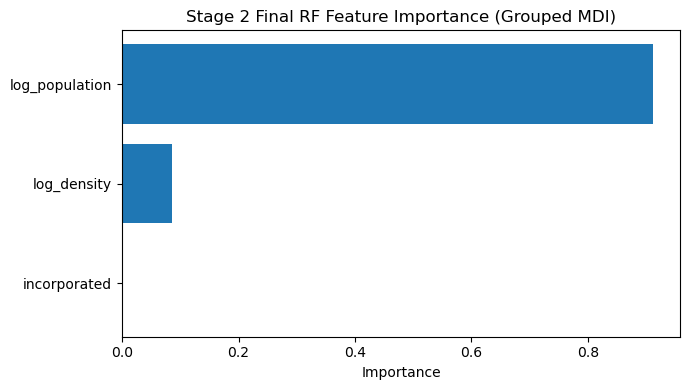

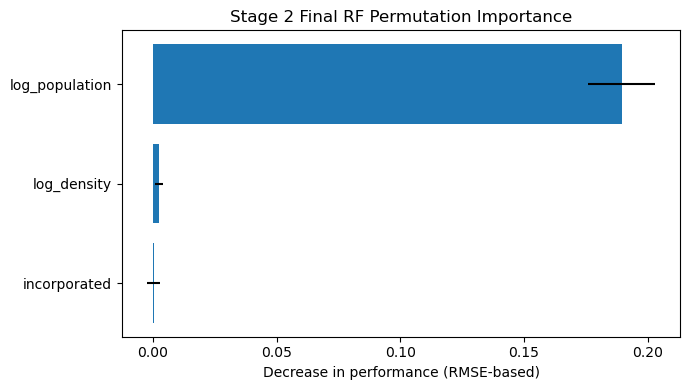


Exported files:
- stage2_final_rf_mdi_importance_detailed.xlsx
- stage2_final_rf_mdi_importance_grouped.xlsx
- stage2_final_rf_permutation_importance.xlsx


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance

# =========================================================
# 1. Retrain the final Stage 2 Random Forest model
#    using the selected A_city_capacity feature set
# =========================================================
final_features_stage2 = [
    "log_population",
    "log_density",
    "incorporated"
]

final_numeric_features = [
    "log_population",
    "log_density"
]

final_categorical_features = [
    "incorporated"
]

X_train_final = df_train[final_features_stage2]
y_train_final = df_train[target]

X_test_final = df_test[final_features_stage2]
y_test_final = df_test[target]

preprocessor_final_rf = build_preprocessor(
    numeric_features=final_numeric_features,
    categorical_features=final_categorical_features,
    scale_numeric=False
)

final_rf_model = Pipeline([
    ("preprocessor", preprocessor_final_rf),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    ))
])

final_rf_model.fit(X_train_final, y_train_final)

# =========================================================
# 2. Extract feature names after one-hot encoding
# =========================================================
preprocessor_fitted = final_rf_model.named_steps["preprocessor"]
rf_fitted = final_rf_model.named_steps["model"]

feature_names_after_transform = preprocessor_fitted.get_feature_names_out()

# =========================================================
# 3. Built-in feature importance (Gini importance / MDI)
# =========================================================
mdi_importance = rf_fitted.feature_importances_

mdi_importance_df = pd.DataFrame({
    "feature": feature_names_after_transform,
    "importance": mdi_importance
}).sort_values("importance", ascending=False)

print("\nMDI feature importance:")
print(mdi_importance_df)

# =========================================================
# 4. Group one-hot encoded feature importance
#    to make interpretation easier
# =========================================================
def map_feature_group(feature_name: str) -> str:
    """Map transformed feature names back to their original feature groups."""
    if "log_population" in feature_name:
        return "log_population"
    elif "log_density" in feature_name:
        return "log_density"
    elif "incorporated" in feature_name:
        return "incorporated"
    else:
        return feature_name

mdi_importance_df["feature_group"] = mdi_importance_df["feature"].map(map_feature_group)

mdi_grouped_df = (
    mdi_importance_df
    .groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

print("\nGrouped MDI feature importance:")
print(mdi_grouped_df)

# =========================================================
# 5. Permutation importance
#    This is generally more suitable for reporting
#    and is computed directly on the original test features
# =========================================================
perm_result = permutation_importance(
    estimator=final_rf_model,
    X=X_test_final,
    y=y_test_final,
    n_repeats=20,
    random_state=42,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    "feature": final_features_stage2,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

print("\nPermutation feature importance:")
print(perm_importance_df)

# =========================================================
# 6. Visualization: grouped MDI importance
# =========================================================
plt.figure(figsize=(7, 4))
plt.barh(
    mdi_grouped_df["feature_group"],
    mdi_grouped_df["importance"]
)
plt.gca().invert_yaxis()
plt.title("Stage 2 Final RF Feature Importance (Grouped MDI)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# =========================================================
# 7. Visualization: permutation importance
# =========================================================
plt.figure(figsize=(7, 4))
plt.barh(
    perm_importance_df["feature"],
    perm_importance_df["importance_mean"],
    xerr=perm_importance_df["importance_std"]
)
plt.gca().invert_yaxis()
plt.title("Stage 2 Final RF Permutation Importance")
plt.xlabel("Decrease in performance (RMSE-based)")
plt.tight_layout()
plt.show()

# =========================================================
# 8. Export results
# =========================================================
mdi_importance_df.to_excel("stage2_final_rf_mdi_importance_detailed.xlsx", index=False)
mdi_grouped_df.to_excel("stage2_final_rf_mdi_importance_grouped.xlsx", index=False)
perm_importance_df.to_excel("stage2_final_rf_permutation_importance.xlsx", index=False)

print("\nExported files:")
print("- stage2_final_rf_mdi_importance_detailed.xlsx")
print("- stage2_final_rf_mdi_importance_grouped.xlsx")
print("- stage2_final_rf_permutation_importance.xlsx")

In [40]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit

# =========================================================
# 0. Prepare Stage 2 data
#    Keep only cities with dealer_count > 0
# =========================================================
df_stage2 = model_df.copy()
df_stage2 = df_stage2[df_stage2["state_full"] != "Puerto Rico"].copy()
df_stage2 = df_stage2[df_stage2["dealer_count"] > 0].copy()

# Group by city to prevent the same city from appearing across train / val / test
df_stage2["city_state_group"] = (
    df_stage2["city_name"].astype(str).str.strip() + " | " +
    df_stage2["state_full"].astype(str).str.strip()
)

print("Stage 2 dataset shape:", df_stage2.shape)
print("Number of unique city groups:", df_stage2["city_state_group"].nunique())
print("\nDealer count distribution:")
print(df_stage2["dealer_count"].value_counts().sort_index())

# =========================================================
# 1. Select Stage 2 features
# =========================================================
features_stage2 = [
    "log_population",
    "log_density",
    "incorporated",
    "cluster_reduced",
    "state_priority_score"
]

target = "dealer_count"

numeric_features = [
    "log_population",
    "log_density",
    "state_priority_score"
]

categorical_features = [
    "incorporated",
    "cluster_reduced"
]

required_cols = (
    features_stage2
    + [target, "city_name", "state_full", "city_state_group"]
)

df_stage2 = df_stage2[required_cols].copy()

# =========================================================
# 2. Group-based train / validation / test split
# =========================================================
X_all = df_stage2[features_stage2]
y_all = df_stage2[target]
groups_all = df_stage2["city_state_group"]

# First split out test = 20%
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_all, y_all, groups=groups_all))

df_train_val = df_stage2.iloc[train_val_idx].copy()
df_test = df_stage2.iloc[test_idx].copy()

# Then split validation = 25% of train_val = 20% overall
X_train_val = df_train_val[features_stage2]
y_train_val = df_train_val[target]
groups_train_val = df_train_val["city_state_group"]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(
    gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
)

df_train = df_train_val.iloc[train_idx_rel].copy()
df_val = df_train_val.iloc[val_idx_rel].copy()

print("\nSplit summary:")
print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

train_groups = set(df_train["city_state_group"])
val_groups = set(df_val["city_state_group"])
test_groups = set(df_test["city_state_group"])

print("\nGroup overlap check:")
print("train ∩ val :", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("val   ∩ test:", len(val_groups & test_groups))

Stage 2 dataset shape: (1037, 52)
Number of unique city groups: 1036

Dealer count distribution:
dealer_count
1    977
2     45
3     10
4      3
5      1
6      1
Name: count, dtype: int64

Split summary:
Train: (621, 9)
Val  : (207, 9)
Test : (209, 9)

Group overlap check:
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0


In [41]:
print(df_train.shape)
print(df_val.shape)
print(df_test.shape)
print(features_stage2)
print(numeric_features)
print(categorical_features)
print(target)

(621, 9)
(207, 9)
(209, 9)
['log_population', 'log_density', 'incorporated', 'cluster_reduced', 'state_priority_score']
['log_population', 'log_density', 'state_priority_score']
['incorporated', 'cluster_reduced']
dealer_count


In [42]:
import numpy as np
import pandas as pd

from itertools import product
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import PoissonRegressor

# =========================================================
# 0. Utility functions
# =========================================================
def regression_metrics(y_true, y_pred):
    """Return MAE, RMSE and R2 for regression outputs."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


def build_preprocessor(numeric_features, categorical_features, scale_numeric=True):
    """Build preprocessing pipeline."""
    if scale_numeric:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return preprocessor


def evaluate_fitted_model(model, X_val, y_val, X_test, y_test):
    """Evaluate a fitted model on validation and test sets."""
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)

    # dealer_count should not be negative
    val_pred = np.clip(val_pred, 0, None)
    test_pred = np.clip(test_pred, 0, None)

    val_metrics = regression_metrics(y_val, val_pred)
    test_metrics = regression_metrics(y_test, test_pred)

    return {
        "val_MAE": val_metrics["MAE"],
        "val_RMSE": val_metrics["RMSE"],
        "val_R2": val_metrics["R2"],
        "test_MAE": test_metrics["MAE"],
        "test_RMSE": test_metrics["RMSE"],
        "test_R2": test_metrics["R2"],
        "val_pred": val_pred,
        "test_pred": test_pred
    }


def pretty_print_summary(title, row_dict):
    print(f"\n--- {title} ---")
    for k, v in row_dict.items():
        if isinstance(v, (int, float, np.floating)):
            print(f"{k}: {round(v, 4)}")
        else:
            print(f"{k}: {v}")


# =========================================================
# 1. Prepare Stage 2 data
#    Keep only cities with dealer_count > 0
# =========================================================
df_stage2 = model_df.copy()
df_stage2 = df_stage2[df_stage2["state_full"] != "Puerto Rico"].copy()
df_stage2 = df_stage2[df_stage2["dealer_count"] > 0].copy()

df_stage2["city_state_group"] = (
    df_stage2["city_name"].astype(str).str.strip() + " | " +
    df_stage2["state_full"].astype(str).str.strip()
)

print("Stage 2 dataset shape:", df_stage2.shape)
print("Number of unique city groups:", df_stage2["city_state_group"].nunique())
print("\nDealer count distribution:")
print(df_stage2["dealer_count"].value_counts().sort_index())

# =========================================================
# 2. Fix the final feature version: A_city_capacity
# =========================================================
features_stage2 = [
    "log_population",
    "log_density",
    "incorporated"
]

target = "dealer_count"

numeric_features = [
    "log_population",
    "log_density"
]

categorical_features = [
    "incorporated"
]

required_cols = features_stage2 + [
    target, "city_name", "state_full", "city_state_group"
]

df_stage2 = df_stage2[required_cols].copy()

print("\nFinal Stage 2 features:", features_stage2)

# =========================================================
# 3. Group-based train / validation / test split
# =========================================================
X_all = df_stage2[features_stage2]
y_all = df_stage2[target]
groups_all = df_stage2["city_state_group"]

# First split out test = 20%
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X_all, y_all, groups=groups_all))

df_train_val = df_stage2.iloc[train_val_idx].copy()
df_test = df_stage2.iloc[test_idx].copy()

# Then split validation = 25% of train_val = 20% overall
X_train_val = df_train_val[features_stage2]
y_train_val = df_train_val[target]
groups_train_val = df_train_val["city_state_group"]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(
    gss_val.split(X_train_val, y_train_val, groups=groups_train_val)
)

df_train = df_train_val.iloc[train_idx_rel].copy()
df_val = df_train_val.iloc[val_idx_rel].copy()

print("\nSplit summary:")
print("Train:", df_train.shape)
print("Val  :", df_val.shape)
print("Test :", df_test.shape)

train_groups = set(df_train["city_state_group"])
val_groups = set(df_val["city_state_group"])
test_groups = set(df_test["city_state_group"])

print("\nGroup overlap check:")
print("train ∩ val :", len(train_groups & val_groups))
print("train ∩ test:", len(train_groups & test_groups))
print("val   ∩ test:", len(val_groups & test_groups))

# =========================================================
# 4. Prepare train / validation / test data
# =========================================================
X_train = df_train[features_stage2]
y_train = df_train[target]

X_val = df_val[features_stage2]
y_val = df_val[target]

X_test = df_test[features_stage2]
y_test = df_test[target]

print("\nTraining / validation / test dimensions:")
print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

# =========================================================
# 5. Light tuning for Poisson
# =========================================================
poisson_alpha_grid = [0.01, 0.1, 1.0, 5.0, 10.0]

poisson_results = []
best_poisson_model = None
best_poisson_score = np.inf

for alpha in poisson_alpha_grid:
    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=True
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", PoissonRegressor(alpha=alpha, max_iter=1000))
    ])

    model.fit(X_train, y_train)

    eval_result = evaluate_fitted_model(
        model=model,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )

    row = {
        "model": "PoissonRegressor",
        "alpha": alpha,
        "val_MAE": eval_result["val_MAE"],
        "val_RMSE": eval_result["val_RMSE"],
        "val_R2": eval_result["val_R2"],
        "test_MAE": eval_result["test_MAE"],
        "test_RMSE": eval_result["test_RMSE"],
        "test_R2": eval_result["test_R2"]
    }
    poisson_results.append(row)

    if eval_result["val_RMSE"] < best_poisson_score:
        best_poisson_score = eval_result["val_RMSE"]
        best_poisson_model = model
        best_poisson_val_pred = eval_result["val_pred"]
        best_poisson_test_pred = eval_result["test_pred"]
        best_poisson_params = {"alpha": alpha}

poisson_results_df = pd.DataFrame(poisson_results).sort_values("val_RMSE")

print("\n===== Poisson tuning results =====")
print(poisson_results_df.round(4))

print("\nBest Poisson parameters:", best_poisson_params)
print("Best Poisson validation RMSE:", round(best_poisson_score, 4))

# =========================================================
# 6. Light tuning for Random Forest
# =========================================================
rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [5, 8, 12, None],
    "min_samples_leaf": [1, 3, 5, 10],
    "max_features": ["sqrt", 0.5, 1.0]
}

rf_results = []
best_rf_model = None
best_rf_score = np.inf

param_combinations = list(product(
    rf_param_grid["n_estimators"],
    rf_param_grid["max_depth"],
    rf_param_grid["min_samples_leaf"],
    rf_param_grid["max_features"]
))

print("\nNumber of Random Forest parameter combinations:", len(param_combinations))

for n_estimators, max_depth, min_samples_leaf, max_features in param_combinations:
    preprocessor = build_preprocessor(
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        scale_numeric=False
    )

    model = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train, y_train)

    eval_result = evaluate_fitted_model(
        model=model,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test
    )

    row = {
        "model": "RandomForestRegressor",
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "min_samples_leaf": min_samples_leaf,
        "max_features": max_features,
        "val_MAE": eval_result["val_MAE"],
        "val_RMSE": eval_result["val_RMSE"],
        "val_R2": eval_result["val_R2"],
        "test_MAE": eval_result["test_MAE"],
        "test_RMSE": eval_result["test_RMSE"],
        "test_R2": eval_result["test_R2"]
    }
    rf_results.append(row)

    if eval_result["val_RMSE"] < best_rf_score:
        best_rf_score = eval_result["val_RMSE"]
        best_rf_model = model
        best_rf_val_pred = eval_result["val_pred"]
        best_rf_test_pred = eval_result["test_pred"]
        best_rf_params = {
            "n_estimators": n_estimators,
            "max_depth": max_depth,
            "min_samples_leaf": min_samples_leaf,
            "max_features": max_features
        }

rf_results_df = pd.DataFrame(rf_results).sort_values("val_RMSE")

print("\n===== Random Forest tuning results (top 20) =====")
print(rf_results_df.head(20).round(4))

print("\nBest Random Forest parameters:", best_rf_params)
print("Best Random Forest validation RMSE:", round(best_rf_score, 4))

# =========================================================
# 7. Compare the best Poisson vs the best Random Forest
# =========================================================
best_poisson_eval = evaluate_fitted_model(
    model=best_poisson_model,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

best_rf_eval = evaluate_fitted_model(
    model=best_rf_model,
    X_val=X_val,
    y_val=y_val,
    X_test=X_test,
    y_test=y_test
)

final_comparison = pd.DataFrame([
    {
        "model": "Best_Poisson",
        "feature_version": "A_city_capacity",
        "features": ", ".join(features_stage2),
        "params": str(best_poisson_params),
        "val_MAE": best_poisson_eval["val_MAE"],
        "val_RMSE": best_poisson_eval["val_RMSE"],
        "val_R2": best_poisson_eval["val_R2"],
        "test_MAE": best_poisson_eval["test_MAE"],
        "test_RMSE": best_poisson_eval["test_RMSE"],
        "test_R2": best_poisson_eval["test_R2"]
    },
    {
        "model": "Best_RF",
        "feature_version": "A_city_capacity",
        "features": ", ".join(features_stage2),
        "params": str(best_rf_params),
        "val_MAE": best_rf_eval["val_MAE"],
        "val_RMSE": best_rf_eval["val_RMSE"],
        "val_R2": best_rf_eval["val_R2"],
        "test_MAE": best_rf_eval["test_MAE"],
        "test_RMSE": best_rf_eval["test_RMSE"],
        "test_R2": best_rf_eval["test_R2"]
    }
]).sort_values("val_RMSE")

print("\n==============================")
print("Stage 2 tuned model comparison (A_city_capacity)")
print("==============================")
print(final_comparison.round(4))

best_final_model_name = final_comparison.iloc[0]["model"]
print("\nBest model based on validation RMSE:", best_final_model_name)

# =========================================================
# 8. Print final results
# =========================================================
best_poisson_row = final_comparison.loc[
    final_comparison["model"] == "Best_Poisson"
].iloc[0]

best_rf_row = final_comparison.loc[
    final_comparison["model"] == "Best_RF"
].iloc[0]

pretty_print_summary("Best Poisson Summary", best_poisson_row.to_dict())
pretty_print_summary("Best RF Summary", best_rf_row.to_dict())

# =========================================================
# 9. Export results
# =========================================================
poisson_results_df.to_excel("stage2_A_city_capacity_poisson_tuning_results.xlsx", index=False)
rf_results_df.to_excel("stage2_A_city_capacity_rf_tuning_results.xlsx", index=False)
final_comparison.to_excel("stage2_A_city_capacity_tuned_model_comparison.xlsx", index=False)

best_poisson_test_result = df_test[["city_name", "state_full", "dealer_count"]].copy()
best_poisson_test_result["pred_dealer_count"] = np.clip(best_poisson_test_pred, 0, None)
best_poisson_test_result["model"] = "Best_Poisson"
best_poisson_test_result["feature_version"] = "A_city_capacity"
best_poisson_test_result["params"] = str(best_poisson_params)

best_rf_test_result = df_test[["city_name", "state_full", "dealer_count"]].copy()
best_rf_test_result["pred_dealer_count"] = np.clip(best_rf_test_pred, 0, None)
best_rf_test_result["model"] = "Best_RF"
best_rf_test_result["feature_version"] = "A_city_capacity"
best_rf_test_result["params"] = str(best_rf_params)

best_poisson_test_result.to_excel("stage2_A_city_capacity_best_poisson_test_predictions.xlsx", index=False)
best_rf_test_result.to_excel("stage2_A_city_capacity_best_rf_test_predictions.xlsx", index=False)

print("\nExported files:")
print("- stage2_A_city_capacity_poisson_tuning_results.xlsx")
print("- stage2_A_city_capacity_rf_tuning_results.xlsx")
print("- stage2_A_city_capacity_tuned_model_comparison.xlsx")
print("- stage2_A_city_capacity_best_poisson_test_predictions.xlsx")
print("- stage2_A_city_capacity_best_rf_test_predictions.xlsx")

Stage 2 dataset shape: (1037, 52)
Number of unique city groups: 1036

Dealer count distribution:
dealer_count
1    977
2     45
3     10
4      3
5      1
6      1
Name: count, dtype: int64

Final Stage 2 features: ['log_population', 'log_density', 'incorporated']

Split summary:
Train: (621, 7)
Val  : (207, 7)
Test : (209, 7)

Group overlap check:
train ∩ val : 0
train ∩ test: 0
val   ∩ test: 0

Training / validation / test dimensions:
Train: (621, 3) (621,)
Val  : (207, 3) (207,)
Test : (209, 3) (209,)

===== Poisson tuning results =====
              model  alpha  val_MAE  val_RMSE  val_R2  test_MAE  test_RMSE  \
0  PoissonRegressor   0.01   0.1563    0.2337  0.2895    0.1761     0.3898   
1  PoissonRegressor   0.10   0.1527    0.2340  0.2878    0.1706     0.3935   
2  PoissonRegressor   1.00   0.1338    0.2427  0.2338    0.1504     0.4156   
3  PoissonRegressor   5.00   0.1328    0.2619  0.1075    0.1511     0.4398   
4  PoissonRegressor  10.00   0.1362    0.2684  0.0632    0.1548 

In [43]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

# =========================================================
# 0. Parameter settings
# =========================================================

# Enter the final Stage 1 threshold here
final_stage1_threshold = 0.77

# Final Stage 1 features (V2_city_plus_cluster)
stage1_features = [
    "log_population",
    "log_density",
    "military",
    "incorporated",
    "cluster_reduced"
]

stage1_numeric_features = [
    "log_population",
    "log_density"
]

stage1_categorical_features = [
    "military",
    "incorporated",
    "cluster_reduced"
]

# Final Stage 2 features (A_city_capacity)
stage2_features = [
    "log_population",
    "log_density",
    "incorporated"
]

stage2_numeric_features = [
    "log_population",
    "log_density"
]

stage2_categorical_features = [
    "incorporated"
]

# =========================================================
# 1. Basic data cleaning
# =========================================================
df_final = model_df.copy()
df_final = df_final[df_final["state_full"] != "Puerto Rico"].copy()

# If duplicate state abbreviation columns exist, they do not affect the main workflow;
# remove them if needed
# df_final = df_final.drop(columns=["state_abbr_state"], errors="ignore")

# Ensure the required base columns are present
required_base_cols = [
    "city_name", "state_full", "dealer_count",
    "log_population", "log_density",
    "military", "incorporated",
    "cluster_reduced"
]

missing_required = [c for c in required_base_cols if c not in df_final.columns]
if missing_required:
    raise ValueError(f"The following required base columns are missing: {missing_required}")

# Create has_dealer if it does not already exist
if "has_dealer" not in df_final.columns:
    df_final["has_dealer"] = (df_final["dealer_count"] > 0).astype(int)

print("Final total sample size:", df_final.shape)
print("Number of cities with dealers:", int((df_final["dealer_count"] > 0).sum()))
print("Number of cities without dealers:", int((df_final["dealer_count"] == 0).sum()))

# =========================================================
# 2. Utility functions
# =========================================================
def build_preprocessor(numeric_features, categorical_features, scale_numeric=True):
    if scale_numeric:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
    else:
        numeric_transformer = Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ])

    categorical_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    return preprocessor


def map_recommended_dealers(pred_value):
    """Convert the Stage 2 continuous prediction into a recommended number of new dealers."""
    if pd.isna(pred_value):
        return np.nan
    if pred_value < 1.5:
        return 1
    elif pred_value < 2.5:
        return 2
    else:
        return 3


# =========================================================
# 3. Train the final Stage 1 model
#    Retrain using all available samples
# =========================================================
X_stage1_all = df_final[stage1_features]
y_stage1_all = df_final["has_dealer"]

stage1_preprocessor = build_preprocessor(
    numeric_features=stage1_numeric_features,
    categorical_features=stage1_categorical_features,
    scale_numeric=True
)

final_stage1_model = Pipeline([
    ("preprocessor", stage1_preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

final_stage1_model.fit(X_stage1_all, y_stage1_all)

# Score all cities
df_final["stage1_prob"] = final_stage1_model.predict_proba(X_stage1_all)[:, 1]
df_final["stage1_candidate_flag"] = (df_final["stage1_prob"] >= final_stage1_threshold).astype(int)

print("\nStage 1 scoring completed")
print("threshold =", final_stage1_threshold)
print("Number of cities predicted as candidates:", int(df_final["stage1_candidate_flag"].sum()))

# =========================================================
# 4. Train the final Stage 2 model
#    Retrain using all cities that already have dealers
# =========================================================
df_stage2_train = df_final[df_final["dealer_count"] > 0].copy()

X_stage2_all = df_stage2_train[stage2_features]
y_stage2_all = df_stage2_train["dealer_count"]

stage2_preprocessor = build_preprocessor(
    numeric_features=stage2_numeric_features,
    categorical_features=stage2_categorical_features,
    scale_numeric=False
)

final_stage2_model = Pipeline([
    ("preprocessor", stage2_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    ))
])

final_stage2_model.fit(X_stage2_all, y_stage2_all)

print("\nFinal Stage 2 Random Forest retraining completed")
print("Number of Stage 2 training samples:", df_stage2_train.shape[0])

# =========================================================
# 5. Generate the expansion candidate pool
#    Conditions:
#    - current dealer_count == 0
#    - Stage 1 probability >= threshold
# =========================================================
candidate_df = df_final[
    (df_final["dealer_count"] == 0) &
    (df_final["stage1_prob"] >= final_stage1_threshold)
].copy()

print("\nNumber of candidate expansion cities:", candidate_df.shape[0])

# Warn early if no candidate cities are found
if candidate_df.shape[0] == 0:
    print("Warning: No candidate cities were identified under the current threshold. Please check whether final_stage1_threshold is too high.")

# =========================================================
# 6. Send candidate cities into the final Stage 2 Random Forest
# =========================================================
if candidate_df.shape[0] > 0:
    X_candidate_stage2 = candidate_df[stage2_features]
    candidate_df["stage2_pred_dealer_count"] = np.clip(
        final_stage2_model.predict(X_candidate_stage2),
        0,
        None
    )

    candidate_df["recommended_new_dealers"] = candidate_df["stage2_pred_dealer_count"].apply(map_recommended_dealers)
else:
    candidate_df["stage2_pred_dealer_count"] = np.nan
    candidate_df["recommended_new_dealers"] = np.nan

# =========================================================
# 7. Create the final expansion recommendation table
# =========================================================
preferred_cols = [
    "city_name",
    "state_full",
    "dealer_count",
    "stage1_prob",
    "stage1_candidate_flag",
    "stage2_pred_dealer_count",
    "recommended_new_dealers",
    "log_population",
    "log_density",
    "incorporated",
    "cluster_reduced",
    "state_priority_score",
    "expansion_priority_band",
    "market_type"
]

existing_cols = [c for c in preferred_cols if c in candidate_df.columns]

final_recommendation_df = candidate_df[existing_cols].copy()

# Sorting logic:
# 1. recommended number of new dealers (descending)
# 2. stage1 probability (descending)
# 3. stage2 predicted dealer count (descending)
sort_cols = [c for c in ["recommended_new_dealers", "stage1_prob", "stage2_pred_dealer_count"] if c in final_recommendation_df.columns]

if sort_cols:
    ascending_flags = [False] * len(sort_cols)
    final_recommendation_df = final_recommendation_df.sort_values(
        by=sort_cols,
        ascending=ascending_flags
    ).reset_index(drop=True)

print("\nPreview of the final expansion recommendation table:")
print(final_recommendation_df.head(20))

# =========================================================
# 8. Generate several commonly used output tables
# =========================================================

# 8.1 Top 20 / Top 50
top20_df = final_recommendation_df.head(20).copy()
top50_df = final_recommendation_df.head(50).copy()

# 8.2 State-level summary
state_summary_df = (
    final_recommendation_df
    .groupby("state_full", as_index=False)
    .agg(
        candidate_cities=("city_name", "count"),
        avg_stage1_prob=("stage1_prob", "mean"),
        avg_stage2_pred_dealer_count=("stage2_pred_dealer_count", "mean"),
        total_recommended_new_dealers=("recommended_new_dealers", "sum")
    )
    .sort_values(
        ["total_recommended_new_dealers", "candidate_cities", "avg_stage1_prob"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

print("\nPreview of state-level summary:")
print(state_summary_df.head(20))

# 8.3 Full city scoring table for future reference
all_city_scoring_df = df_final.copy()

# For cities that already have dealers, generate Stage 2 fitted values for comparison
all_city_scoring_df["stage2_fitted_if_positive"] = np.nan
positive_mask = all_city_scoring_df["dealer_count"] > 0
if positive_mask.sum() > 0:
    all_city_scoring_df.loc[positive_mask, "stage2_fitted_if_positive"] = np.clip(
        final_stage2_model.predict(all_city_scoring_df.loc[positive_mask, stage2_features]),
        0,
        None
    )

# For cities without dealers, generate Stage 2 extrapolated values
zero_mask = all_city_scoring_df["dealer_count"] == 0
if zero_mask.sum() > 0:
    all_city_scoring_df.loc[zero_mask, "stage2_pred_if_expand"] = np.clip(
        final_stage2_model.predict(all_city_scoring_df.loc[zero_mask, stage2_features]),
        0,
        None
    )
    all_city_scoring_df.loc[zero_mask, "recommended_new_dealers_if_expand"] = (
        all_city_scoring_df.loc[zero_mask, "stage2_pred_if_expand"].apply(map_recommended_dealers)
    )

# =========================================================
# 9. Export files
# =========================================================
final_recommendation_df.to_excel("final_expansion_recommendations.xlsx", index=False)
top20_df.to_excel("top20_expansion_recommendations.xlsx", index=False)
top50_df.to_excel("top50_expansion_recommendations.xlsx", index=False)
state_summary_df.to_excel("state_level_expansion_summary.xlsx", index=False)
all_city_scoring_df.to_excel("all_city_scoring_with_stage1_stage2.xlsx", index=False)

print("\nExported files:")
print("- final_expansion_recommendations.xlsx")
print("- top20_expansion_recommendations.xlsx")
print("- top50_expansion_recommendations.xlsx")
print("- state_level_expansion_summary.xlsx")
print("- all_city_scoring_with_stage1_stage2.xlsx")

Final total sample size: (30976, 51)
Number of cities with dealers: 1037
Number of cities without dealers: 29939

Stage 1 scoring completed
threshold = 0.77
Number of cities predicted as candidates: 2352

Final Stage 2 Random Forest retraining completed
Number of Stage 2 training samples: 1037

Number of candidate expansion cities: 1563

Preview of the final expansion recommendation table:
         city_name            state_full  dealer_count  stage1_prob  \
0       Washington  District of Columbia             0     0.999975   
1          Detroit              Michigan             0     0.999903   
2      Minneapolis             Minnesota             0     0.999861   
3           Queens              New York             0     0.999764   
4        Manhattan              New York             0     0.999607   
5          McAllen                 Texas             0     0.998852   
6           Dayton                  Ohio             0     0.998790   
7       Cape Coral               Florid

In [44]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ================================
# 1. Load the state-level summary table
# ================================
state_summary_df = pd.read_excel("state_level_expansion_summary.xlsx")

# State name -> state abbreviation
state_abbr_map = {
    "Alabama": "AL", "Alaska": "AK", "Arizona": "AZ", "Arkansas": "AR",
    "California": "CA", "Colorado": "CO", "Connecticut": "CT", "Delaware": "DE",
    "District of Columbia": "DC", "Florida": "FL", "Georgia": "GA", "Hawaii": "HI",
    "Idaho": "ID", "Illinois": "IL", "Indiana": "IN", "Iowa": "IA",
    "Kansas": "KS", "Kentucky": "KY", "Louisiana": "LA", "Maine": "ME",
    "Maryland": "MD", "Massachusetts": "MA", "Michigan": "MI", "Minnesota": "MN",
    "Mississippi": "MS", "Missouri": "MO", "Montana": "MT", "Nebraska": "NE",
    "Nevada": "NV", "New Hampshire": "NH", "New Jersey": "NJ", "New Mexico": "NM",
    "New York": "NY", "North Carolina": "NC", "North Dakota": "ND", "Ohio": "OH",
    "Oklahoma": "OK", "Oregon": "OR", "Pennsylvania": "PA", "Rhode Island": "RI",
    "South Carolina": "SC", "South Dakota": "SD", "Tennessee": "TN", "Texas": "TX",
    "Utah": "UT", "Vermont": "VT", "Virginia": "VA", "Washington": "WA",
    "West Virginia": "WV", "Wisconsin": "WI", "Wyoming": "WY"
}

# Approximate state centroid coordinates
state_label_coords = {
    "AL": (-86.8, 32.8), "AK": (-152.0, 64.0), "AZ": (-111.7, 34.2), "AR": (-92.4, 34.9),
    "CA": (-119.5, 37.2), "CO": (-105.5, 39.0), "CT": (-72.7, 41.6), "DE": (-75.5, 39.0),
    "DC": (-77.0, 38.9), "FL": (-82.5, 28.1), "GA": (-83.5, 32.7), "HI": (-157.5, 20.8),
    "ID": (-114.5, 44.2), "IL": (-89.2, 40.0), "IN": (-86.1, 40.0), "IA": (-93.5, 42.1),
    "KS": (-98.0, 38.5), "KY": (-84.8, 37.5), "LA": (-91.9, 31.0), "ME": (-69.0, 45.2),
    "MD": (-76.7, 39.0), "MA": (-71.8, 42.3), "MI": (-85.5, 44.5), "MN": (-94.5, 46.0),
    "MS": (-89.7, 32.7), "MO": (-92.5, 38.5), "MT": (-109.6, 46.9), "NE": (-99.7, 41.5),
    "NV": (-117.0, 39.3), "NH": (-71.6, 43.9), "NJ": (-74.5, 40.1), "NM": (-106.0, 34.4),
    "NY": (-75.5, 42.9), "NC": (-79.4, 35.5), "ND": (-100.5, 47.5), "OH": (-82.8, 40.3),
    "OK": (-97.5, 35.6), "OR": (-120.5, 43.9), "PA": (-77.8, 40.9), "RI": (-71.5, 41.7),
    "SC": (-80.9, 33.8), "SD": (-100.2, 44.4), "TN": (-86.4, 35.8), "TX": (-99.3, 31.5),
    "UT": (-111.6, 39.3), "VT": (-72.7, 44.0), "VA": (-78.7, 37.5), "WA": (-120.7, 47.4),
    "WV": (-80.6, 38.6), "WI": (-89.9, 44.6), "WY": (-107.6, 43.0)
}

# ================================
# 2. Prepare plotting data
# ================================
plot_df = state_summary_df.copy()
plot_df["state_abbr"] = plot_df["state_full"].map(state_abbr_map)
plot_df = plot_df.dropna(subset=["state_abbr"]).copy()

plot_df["lon"] = plot_df["state_abbr"].map(lambda x: state_label_coords.get(x, (None, None))[0])
plot_df["lat"] = plot_df["state_abbr"].map(lambda x: state_label_coords.get(x, (None, None))[1])

# Display "state abbreviation + recommended expansion count" inside each state
plot_df["state_text"] = (
    plot_df["state_abbr"].astype(str) +
    "<br>" +
    plot_df["total_recommended_new_dealers"].round(0).astype(int).astype(str)
)

# ================================
# 3. Draw base choropleth map (continuous scale)
# ================================
fig = px.choropleth(
    plot_df,
    locations="state_abbr",
    locationmode="USA-states",
    color="total_recommended_new_dealers",
    hover_name="state_full",
    hover_data={
        "state_abbr": False,
        "candidate_cities": True,
        "avg_stage1_prob": ":.3f",
        "avg_stage2_pred_dealer_count": ":.3f",
        "total_recommended_new_dealers": True
    },
    scope="usa",
    color_continuous_scale="Blues",
    title="Recommended New Toyota Dealerships by State"
)

# ================================
# 4. Add in-state text labels
#    Format: state abbreviation + count
# ================================
fig.add_trace(
    go.Scattergeo(
        locationmode="USA-states",
        lon=plot_df["lon"],
        lat=plot_df["lat"],
        text=plot_df["state_text"],
        mode="text",
        textfont=dict(size=12, color="black"),
        showlegend=False,
        hoverinfo="skip"
    )
)

# ================================
# 5. Refine legend and layout
# ================================
fig.update_layout(
    width=1400,
    height=850,
    margin=dict(l=20, r=20, t=70, b=20),
    title=dict(
        text="Recommended New Toyota Dealerships by State",
        x=0.5,
        xanchor="center"
    ),
    coloraxis_colorbar=dict(
        title="Recommended<br>new dealers",
        tickmode="linear",
        dtick=1
    ),
    geo=dict(
        bgcolor="white"
    )
)

fig.show()

Total recommended new dealers in the long-term pipeline: 1577

Preview of annual scenario results:
        scenario  year  planned_new_dealers  realized_new_dealers  \
0   Conservative  2026                   79                    67   
1   Conservative  2027                  110                    94   
2   Conservative  2028                  126                   107   
3   Conservative  2029                  142                   121   
4   Conservative  2030                  158                   134   
5   Conservative  2031                  173                   147   
6   Conservative  2032                  189                   161   
7   Conservative  2033                  189                   161   
8   Conservative  2034                  205                   174   
9   Conservative  2035                  206                   175   
10          Base  2026                   79                    71   
11          Base  2027                  110                    99   
12  

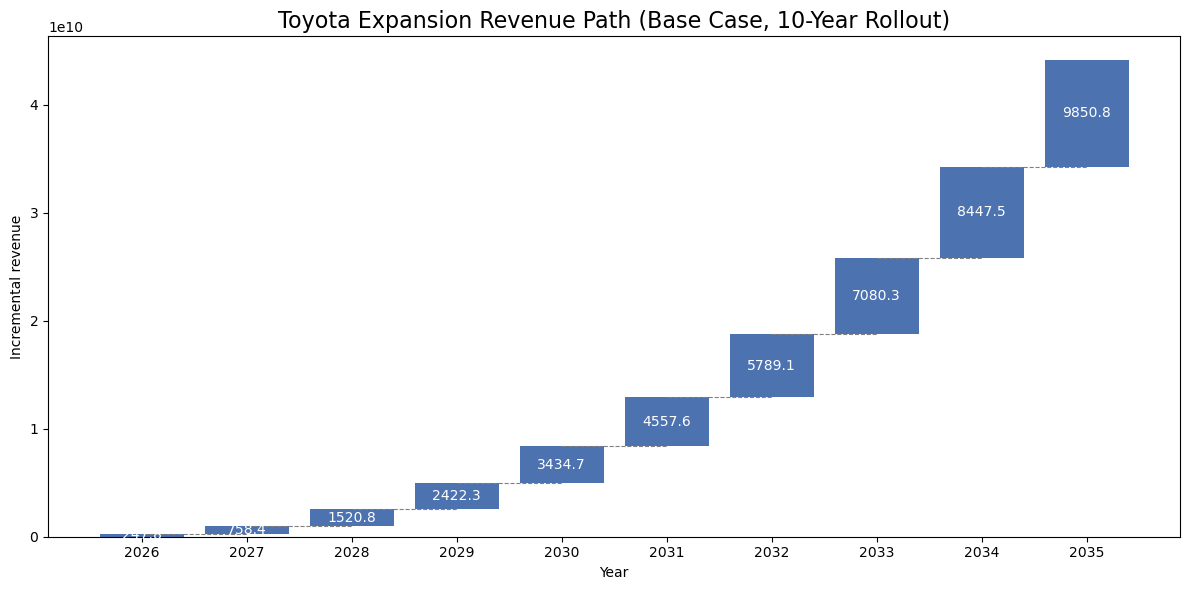

Exported: toyota_10y_base_revenue_waterfall.png


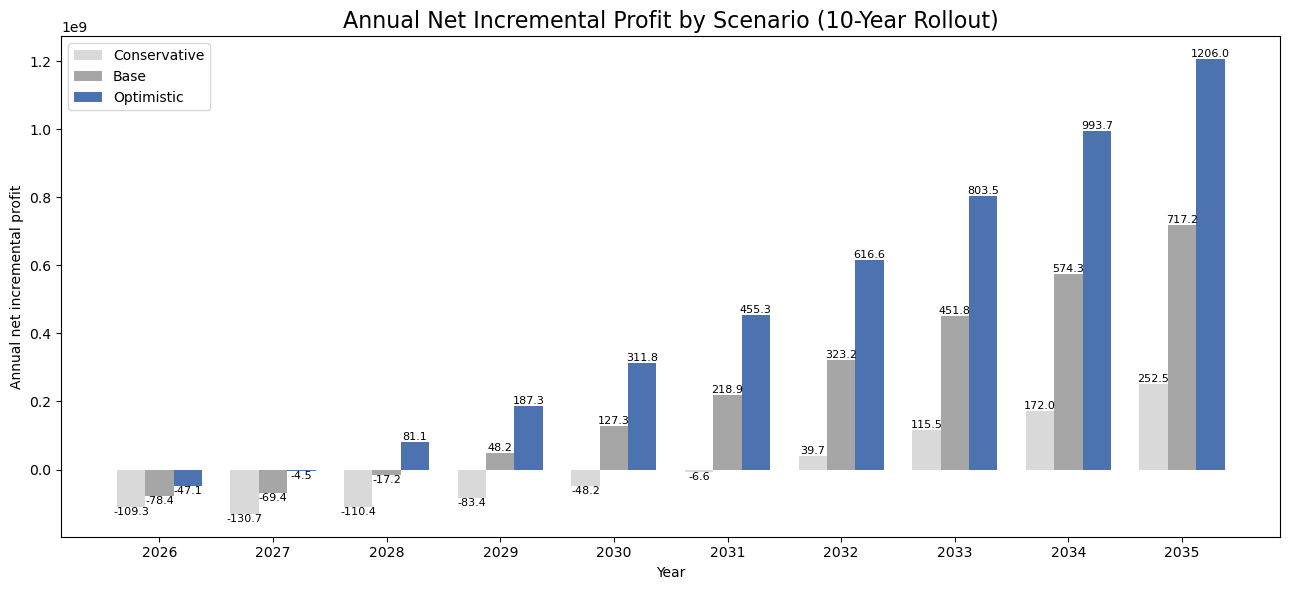

Exported: toyota_10y_annual_profit_by_scenario.png


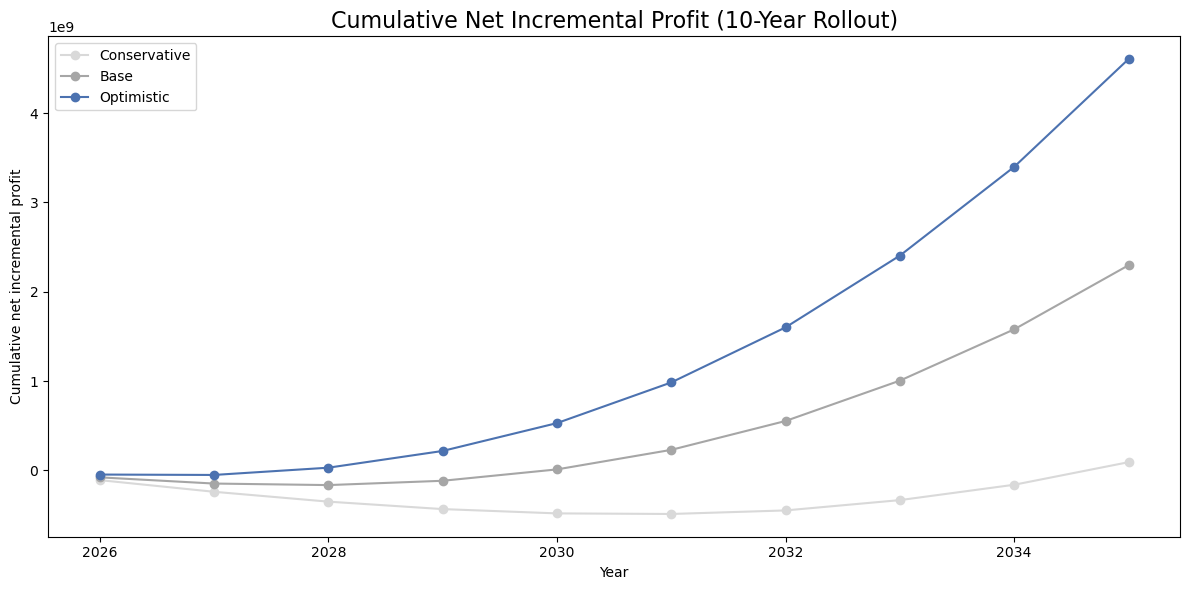

Exported: toyota_10y_cumulative_profit_lines.png


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 0. Load the final expansion recommendation table
# =========================================================
recommend_df = pd.read_excel("final_expansion_recommendations.xlsx")

long_run_recommended_new_dealers = recommend_df["recommended_new_dealers"].sum()
print("Total recommended new dealers in the long-term pipeline:", long_run_recommended_new_dealers)

# =========================================================
# 1. Sales baseline from financial reporting
#    (based on the sales summary you uploaded earlier)
# =========================================================
TMNA_YTD_SALES = 1_236_739
TOYOTA_DIV_YTD_SALES = 1_057_773

# =========================================================
# 2. Set the rollout horizon
#    Recommended main case: 10 years
# =========================================================
horizon_years = 10
start_year = 2026

years = list(range(start_year, start_year + horizon_years))

# =========================================================
# 3. Define rollout shares
#    10-year version: slower early years, faster later years
#    and the total must sum to 1
# =========================================================
rollout_shares_10y = np.array([0.05, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.12, 0.13, 0.13])
assert np.isclose(rollout_shares_10y.sum(), 1.0)

# Optional 5-year version for future use
rollout_shares_5y = np.array([0.12, 0.16, 0.20, 0.24, 0.28])
assert np.isclose(rollout_shares_5y.sum(), 1.0)

rollout_shares = rollout_shares_10y if horizon_years == 10 else rollout_shares_5y

# =========================================================
# 4. Scenario assumptions
#    Key parameters:
#    - ramp_profile: post-opening ramp-up curve for each dealer cohort
#    - annual_cost_decline: support cost per dealer declines over time
#    - annual_profit_growth: profit per unit gradually increases
# =========================================================
scenario_inputs = {
    "Conservative": {
        "execution_rate": 0.85,
        "units_per_dealer_mature": 210,
        "asp_per_unit": 32000,
        "profit_per_unit": 2300,
        "cost_per_dealer_year1": 1_800_000,
        "annual_cost_decline": 0.00,
        "annual_profit_growth": 0.00,
        "ramp_profile": {1: 0.35, 2: 0.70, 3: 1.00}
    },
    "Base": {
        "execution_rate": 0.90,
        "units_per_dealer_mature": 235,
        "asp_per_unit": 33000,
        "profit_per_unit": 2800,
        "cost_per_dealer_year1": 1_400_000,
        "annual_cost_decline": 0.03,
        "annual_profit_growth": 0.01,
        "ramp_profile": {1: 0.45, 2: 0.75, 3: 1.00}
    },
    "Optimistic": {
        "execution_rate": 0.95,
        "units_per_dealer_mature": 260,
        "asp_per_unit": 34000,
        "profit_per_unit": 3300,
        "cost_per_dealer_year1": 1_100_000,
        "annual_cost_decline": 0.04,
        "annual_profit_growth": 0.015,
        "ramp_profile": {1: 0.55, 2: 0.85, 3: 1.00}
    }
}

# =========================================================
# 5. Simulation function
# =========================================================
def get_ramp_factor(age, ramp_profile):
    """
    age = 1 means the first year after opening
    age = 2 means the second year
    age >= 3 uses the mature value
    """
    if age in ramp_profile:
        return ramp_profile[age]
    return ramp_profile[max(ramp_profile.keys())]


def simulate_rollout(long_run_target, years, rollout_shares, scenario_name, params):
    rows = []

    # Planned new dealer openings allocated across the long-term target
    planned_openings = long_run_target * rollout_shares

    # Round openings to integers and adjust the total if needed
    planned_openings = np.round(planned_openings).astype(int)
    diff = int(long_run_target - planned_openings.sum())
    if diff != 0:
        planned_openings[-1] += diff

    # Realized openings = planned openings * execution rate
    realized_openings = np.round(planned_openings * params["execution_rate"]).astype(int)

    # Store new dealer cohorts by year
    cohort_openings = {}

    for i, year in enumerate(years):
        planned_new = planned_openings[i]
        realized_new = realized_openings[i]
        cohort_openings[year] = realized_new

        annual_incremental_units = 0.0
        annual_incremental_revenue = 0.0
        annual_gross_profit = 0.0

        # Profit per unit and per-dealer support cost may change slightly over time
        profit_per_unit_t = params["profit_per_unit"] * ((1 + params["annual_profit_growth"]) ** i)
        cost_per_dealer_t = params["cost_per_dealer_year1"] * ((1 - params["annual_cost_decline"]) ** i)

        # Contribution of all historical cohorts in the current year
        for cohort_year, opened_count in cohort_openings.items():
            age = year - cohort_year + 1
            ramp_factor = get_ramp_factor(age, params["ramp_profile"])

            units_from_cohort = opened_count * params["units_per_dealer_mature"] * ramp_factor
            revenue_from_cohort = units_from_cohort * params["asp_per_unit"]
            gross_profit_from_cohort = units_from_cohort * profit_per_unit_t

            annual_incremental_units += units_from_cohort
            annual_incremental_revenue += revenue_from_cohort
            annual_gross_profit += gross_profit_from_cohort

        # Only newly opened dealers incur first-year expansion cost
        annual_expansion_cost = realized_new * cost_per_dealer_t
        annual_net_profit = annual_gross_profit - annual_expansion_cost

        rows.append({
            "scenario": scenario_name,
            "year": year,
            "planned_new_dealers": planned_new,
            "realized_new_dealers": realized_new,
            "cumulative_open_dealers": sum(v for k, v in cohort_openings.items() if k <= year),
            "incremental_units": annual_incremental_units,
            "incremental_units_pct_of_tmna_ytd_sales": annual_incremental_units / TMNA_YTD_SALES,
            "incremental_revenue": annual_incremental_revenue,
            "annual_gross_incremental_profit": annual_gross_profit,
            "annual_expansion_cost": annual_expansion_cost,
            "annual_net_incremental_profit": annual_net_profit
        })

    df = pd.DataFrame(rows)

    # Add cumulative values for charting
    df["cumulative_incremental_revenue"] = df["incremental_revenue"].cumsum()
    df["cumulative_net_incremental_profit"] = df["annual_net_incremental_profit"].cumsum()

    return df


# =========================================================
# 6. Run the three scenarios
# =========================================================
all_scenario_results = []

for scenario_name, params in scenario_inputs.items():
    df_s = simulate_rollout(
        long_run_target=long_run_recommended_new_dealers,
        years=years,
        rollout_shares=rollout_shares,
        scenario_name=scenario_name,
        params=params
    )
    all_scenario_results.append(df_s)

annual_scenario_df = pd.concat(all_scenario_results, ignore_index=True)

print("\nPreview of annual scenario results:")
print(annual_scenario_df.head(20))

annual_scenario_df.to_excel("toyota_10y_rollout_scenarios_by_year.xlsx", index=False)
print("Exported: toyota_10y_rollout_scenarios_by_year.xlsx")

# =========================================================
# 7. Create a compact summary table
# =========================================================
summary_df = (
    annual_scenario_df.groupby("scenario", as_index=False)
    .agg(
        total_realized_new_dealers=("realized_new_dealers", "sum"),
        final_year_incremental_units=("incremental_units", "last"),
        final_year_incremental_revenue=("incremental_revenue", "last"),
        final_year_net_incremental_profit=("annual_net_incremental_profit", "last"),
        cumulative_incremental_revenue_10y=("incremental_revenue", "sum"),
        cumulative_net_incremental_profit_10y=("annual_net_incremental_profit", "sum")
    )
)

summary_df.to_excel("toyota_10y_rollout_scenarios_summary.xlsx", index=False)
print("Exported: toyota_10y_rollout_scenarios_summary.xlsx")

# =========================================================
# 8. Chart 1: Base case cumulative revenue waterfall-style chart
# =========================================================
base_df = annual_scenario_df[annual_scenario_df["scenario"] == "Base"].copy()

fig, ax = plt.subplots(figsize=(12, 6))

x_labels = [str(y) for y in base_df["year"]]
values = base_df["incremental_revenue"].values

bottoms = np.cumsum(np.insert(values[:-1], 0, 0))

bars = ax.bar(x_labels, values, bottom=bottoms, color="#4C72B0")

# Connector lines
for i in range(len(values) - 1):
    y = bottoms[i] + values[i]
    ax.plot([i, i + 1], [y, y], linestyle="--", linewidth=0.8, color="gray")

# Value labels
for i, (b, v) in enumerate(zip(bottoms, values)):
    ax.text(i, b + v / 2, f"{v/1e6:.1f}", ha="center", va="center", color="white", fontsize=10)

ax.set_title("Toyota Expansion Revenue Path (Base Case, 10-Year Rollout)", fontsize=16)
ax.set_ylabel("Incremental revenue")
ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig("toyota_10y_base_revenue_waterfall.png", dpi=300, bbox_inches="tight")
plt.show()

print("Exported: toyota_10y_base_revenue_waterfall.png")

# =========================================================
# 9. Chart 2: Annual net profit by scenario
# =========================================================
plot_df = annual_scenario_df.copy()

pivot_profit = plot_df.pivot(index="year", columns="scenario", values="annual_net_incremental_profit")

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(pivot_profit.index))
width = 0.25

scenarios = ["Conservative", "Base", "Optimistic"]
colors = ["#D9D9D9", "#A6A6A6", "#4C72B0"]

for i, (sc, color) in enumerate(zip(scenarios, colors)):
    vals = pivot_profit[sc].values
    bars = ax.bar(x + (i - 1) * width, vals, width=width, label=sc, color=color)

    for bx, v in zip(x + (i - 1) * width, vals):
        ax.text(bx, v, f"{v/1e6:.1f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(pivot_profit.index.astype(str))
ax.set_title("Annual Net Incremental Profit by Scenario (10-Year Rollout)", fontsize=16)
ax.set_ylabel("Annual net incremental profit")
ax.set_xlabel("Year")
ax.legend()

plt.tight_layout()
plt.savefig("toyota_10y_annual_profit_by_scenario.png", dpi=300, bbox_inches="tight")
plt.show()

print("Exported: toyota_10y_annual_profit_by_scenario.png")

# =========================================================
# 10. Chart 3: Cumulative net profit by scenario
# =========================================================
fig, ax = plt.subplots(figsize=(12, 6))

for sc, color in zip(scenarios, colors):
    df_sc = annual_scenario_df[annual_scenario_df["scenario"] == sc]
    ax.plot(
        df_sc["year"],
        df_sc["cumulative_net_incremental_profit"],
        marker="o",
        label=sc,
        color=color
    )

ax.set_title("Cumulative Net Incremental Profit (10-Year Rollout)", fontsize=16)
ax.set_ylabel("Cumulative net incremental profit")
ax.set_xlabel("Year")
ax.legend()

plt.tight_layout()
plt.savefig("toyota_10y_cumulative_profit_lines.png", dpi=300, bbox_inches="tight")
plt.show()

print("Exported: toyota_10y_cumulative_profit_lines.png")

In [46]:
import numpy as np
import pandas as pd

# =========================================================
# 0. Load the final expansion recommendation table
# =========================================================
recommend_df = pd.read_excel("final_expansion_recommendations.xlsx")

# Sort once more to ensure priority order is explicit
recommend_df = recommend_df.sort_values(
    by=["recommended_new_dealers", "stage1_prob", "stage2_pred_dealer_count"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Keep only the fields needed for scheduling
base_schedule_df = recommend_df[
    [
        "city_name",
        "state_full",
        "recommended_new_dealers",
        "stage1_prob",
        "stage2_pred_dealer_count"
    ]
].copy()

base_schedule_df["recommended_new_dealers"] = base_schedule_df["recommended_new_dealers"].astype(int)

print("Number of candidate cities:", len(base_schedule_df))
print("Total recommended new dealers in the long-term plan:", base_schedule_df["recommended_new_dealers"].sum())

# =========================================================
# 1. Set the horizon and rollout shares
# =========================================================
horizon_years = 10
start_year = 2026
years = list(range(start_year, start_year + horizon_years))

rollout_shares_10y = np.array([0.05, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.12, 0.13, 0.13])
assert np.isclose(rollout_shares_10y.sum(), 1.0)

rollout_shares = rollout_shares_10y

# =========================================================
# 2. Scenario parameters
#    Here we only use execution_rate for yearly rollout scheduling
# =========================================================
scenario_inputs = {
    "Conservative": {
        "execution_rate": 0.85
    },
    "Base": {
        "execution_rate": 0.90
    },
    "Optimistic": {
        "execution_rate": 0.95
    }
}

# =========================================================
# 3. Define the scheduling function for a single scenario
# =========================================================
def build_rollout_schedule_for_scenario(
    recommend_df_sorted: pd.DataFrame,
    scenario_name: str,
    execution_rate: float,
    years: list,
    rollout_shares: np.ndarray
):
    """
    This step creates a city-level rollout schedule, not a financial simulation.

    Logic:
    1. Split the total long-term recommended dealer count into annual quotas using rollout shares.
    2. Apply the execution rate to derive the realized quota under each scenario.
    3. Allocate openings according to the final recommendation ranking, starting with the highest-priority cities.
    4. If a city is recommended for 3 dealers but the annual quota is not sufficient, allocation continues into later years.
    """

    # Copy the input to avoid modifying the original table
    work_df = recommend_df_sorted.copy()
    work_df["remaining_dealers_to_open"] = work_df["recommended_new_dealers"].astype(int)

    long_run_target = int(work_df["recommended_new_dealers"].sum())

    # ---------- Annual planned openings ----------
    planned_openings = np.round(long_run_target * rollout_shares).astype(int)
    diff_planned = int(long_run_target - planned_openings.sum())
    if diff_planned != 0:
        planned_openings[-1] += diff_planned

    # ---------- Annual realized openings ----------
    realized_openings = np.round(planned_openings * execution_rate).astype(int)
    realized_target = int(np.round(long_run_target * execution_rate))
    diff_realized = int(realized_target - realized_openings.sum())
    if diff_realized != 0:
        realized_openings[-1] += diff_realized

    # ---------- Annual quota table ----------
    year_quota_df = pd.DataFrame({
        "scenario": scenario_name,
        "year": years,
        "planned_new_dealers": planned_openings,
        "realized_new_dealers_quota": realized_openings
    })

    # ---------- Year-by-year city-level allocation ----------
    city_rows = []

    for year, quota in zip(years, realized_openings):
        remaining_quota_this_year = int(quota)

        for idx in work_df.index:
            if remaining_quota_this_year <= 0:
                break

            city_remaining = int(work_df.at[idx, "remaining_dealers_to_open"])
            if city_remaining <= 0:
                continue

            open_now = min(city_remaining, remaining_quota_this_year)

            if open_now > 0:
                work_df.at[idx, "remaining_dealers_to_open"] -= open_now
                remaining_quota_this_year -= open_now

                city_rows.append({
                    "scenario": scenario_name,
                    "year": year,
                    "city_name": work_df.at[idx, "city_name"],
                    "state_full": work_df.at[idx, "state_full"],
                    "dealers_opened_this_year": int(open_now),
                    "remaining_after_year": int(work_df.at[idx, "remaining_dealers_to_open"]),
                    "recommended_new_dealers_total": int(work_df.at[idx, "recommended_new_dealers"]),
                    "stage1_prob": float(work_df.at[idx, "stage1_prob"]),
                    "stage2_pred_dealer_count": float(work_df.at[idx, "stage2_pred_dealer_count"])
                })

    city_schedule_df = pd.DataFrame(city_rows)

    # ---------- State-level annual summary ----------
    state_schedule_df = (
        city_schedule_df
        .groupby(["scenario", "year", "state_full"], as_index=False)
        .agg(
            new_dealers_this_year=("dealers_opened_this_year", "sum"),
            cities_activated=("city_name", "nunique")
        )
        .sort_values(
            ["scenario", "year", "new_dealers_this_year", "cities_activated"],
            ascending=[True, True, False, False]
        )
        .reset_index(drop=True)
    )

    # ---------- State × year wide table ----------
    state_schedule_wide_df = (
        state_schedule_df
        .pivot_table(
            index=["scenario", "state_full"],
            columns="year",
            values="new_dealers_this_year",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    year_cols_state = [c for c in state_schedule_wide_df.columns if isinstance(c, (int, np.integer))]
    state_schedule_wide_df["total_2026_2035"] = state_schedule_wide_df[year_cols_state].sum(axis=1)
    state_schedule_wide_df = state_schedule_wide_df.sort_values(
        by=["scenario", "total_2026_2035"],
        ascending=[True, False]
    ).reset_index(drop=True)

    # ---------- City × year wide table ----------
    city_schedule_wide_df = (
        city_schedule_df
        .pivot_table(
            index=[
                "scenario",
                "city_name",
                "state_full",
                "recommended_new_dealers_total",
                "stage1_prob",
                "stage2_pred_dealer_count"
            ],
            columns="year",
            values="dealers_opened_this_year",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    year_cols_city = [c for c in city_schedule_wide_df.columns if isinstance(c, (int, np.integer))]
    city_schedule_wide_df["total_assigned"] = city_schedule_wide_df[year_cols_city].sum(axis=1)
    city_schedule_wide_df = city_schedule_wide_df.sort_values(
        by=["scenario", "total_assigned", "stage1_prob", "stage2_pred_dealer_count"],
        ascending=[True, False, False, False]
    ).reset_index(drop=True)

    return (
        year_quota_df,
        city_schedule_df,
        state_schedule_df,
        state_schedule_wide_df,
        city_schedule_wide_df
    )

# =========================================================
# 4. Run all three scenarios
# =========================================================
all_year_quota = []
all_city_schedule = []
all_state_schedule = []
all_state_schedule_wide = []
all_city_schedule_wide = []

for scenario_name, params in scenario_inputs.items():
    print(f"\nGenerating rollout schedule for the {scenario_name} scenario...")

    (
        year_quota_df,
        city_schedule_df,
        state_schedule_df,
        state_schedule_wide_df,
        city_schedule_wide_df
    ) = build_rollout_schedule_for_scenario(
        recommend_df_sorted=base_schedule_df,
        scenario_name=scenario_name,
        execution_rate=params["execution_rate"],
        years=years,
        rollout_shares=rollout_shares
    )

    all_year_quota.append(year_quota_df)
    all_city_schedule.append(city_schedule_df)
    all_state_schedule.append(state_schedule_df)
    all_state_schedule_wide.append(state_schedule_wide_df)
    all_city_schedule_wide.append(city_schedule_wide_df)

    # Export each scenario separately
    safe_name = scenario_name.lower()

    year_quota_df.to_excel(f"rollout_year_quota_{safe_name}.xlsx", index=False)
    city_schedule_df.to_excel(f"city_level_rollout_schedule_{safe_name}.xlsx", index=False)
    state_schedule_df.to_excel(f"state_level_rollout_schedule_{safe_name}.xlsx", index=False)
    state_schedule_wide_df.to_excel(f"state_level_rollout_schedule_{safe_name}_wide.xlsx", index=False)
    city_schedule_wide_df.to_excel(f"city_level_rollout_schedule_{safe_name}_wide.xlsx", index=False)

# =========================================================
# 5. Combine the three scenarios into master tables
# =========================================================
all_year_quota_df = pd.concat(all_year_quota, ignore_index=True)
all_city_schedule_df = pd.concat(all_city_schedule, ignore_index=True)
all_state_schedule_df = pd.concat(all_state_schedule, ignore_index=True)
all_state_schedule_wide_df = pd.concat(all_state_schedule_wide, ignore_index=True)
all_city_schedule_wide_df = pd.concat(all_city_schedule_wide, ignore_index=True)

# =========================================================
# 6. Create several summary tables for reporting
# =========================================================

# 6.1 State-level total additions across the three scenarios
state_total_summary_df = (
    all_state_schedule_df
    .groupby(["scenario", "state_full"], as_index=False)
    .agg(
        total_new_dealers_2026_2035=("new_dealers_this_year", "sum"),
        total_city_activations=("cities_activated", "sum")
    )
    .sort_values(["scenario", "total_new_dealers_2026_2035"], ascending=[True, False])
    .reset_index(drop=True)
)

# 6.2 City-level total additions across the three scenarios
city_total_summary_df = (
    all_city_schedule_df
    .groupby(
        ["scenario", "city_name", "state_full", "recommended_new_dealers_total", "stage1_prob", "stage2_pred_dealer_count"],
        as_index=False
    )
    .agg(
        total_opened_2026_2035=("dealers_opened_this_year", "sum")
    )
    .sort_values(["scenario", "total_opened_2026_2035", "stage1_prob"], ascending=[True, False, False])
    .reset_index(drop=True)
)

# 6.3 Annual summary across the three scenarios
scenario_year_summary_df = (
    all_year_quota_df
    .groupby(["scenario", "year"], as_index=False)
    .agg(
        planned_new_dealers=("planned_new_dealers", "sum"),
        realized_new_dealers_quota=("realized_new_dealers_quota", "sum")
    )
)

# =========================================================
# 7. Export combined master tables
# =========================================================
all_year_quota_df.to_excel("all_scenarios_rollout_year_quota.xlsx", index=False)
all_city_schedule_df.to_excel("all_scenarios_city_level_rollout_schedule.xlsx", index=False)
all_state_schedule_df.to_excel("all_scenarios_state_level_rollout_schedule.xlsx", index=False)
all_state_schedule_wide_df.to_excel("all_scenarios_state_level_rollout_schedule_wide.xlsx", index=False)
all_city_schedule_wide_df.to_excel("all_scenarios_city_level_rollout_schedule_wide.xlsx", index=False)

state_total_summary_df.to_excel("all_scenarios_state_total_summary.xlsx", index=False)
city_total_summary_df.to_excel("all_scenarios_city_total_summary.xlsx", index=False)
scenario_year_summary_df.to_excel("all_scenarios_year_summary.xlsx", index=False)

# =========================================================
# 8. Print previews
# =========================================================
print("\n========== Preview: annual quotas across the three scenarios ==========")
print(all_year_quota_df.head(15))

print("\n========== Preview: city-level rollout schedule across the three scenarios ==========")
print(all_city_schedule_df.head(20))

print("\n========== Preview: state-level rollout schedule across the three scenarios ==========")
print(all_state_schedule_df.head(20))

print("\n========== Preview: state-level total additions across the three scenarios ==========")
print(state_total_summary_df.head(15))

print("\n========== Exported files ==========")

for scenario_name in scenario_inputs.keys():
    safe_name = scenario_name.lower()
    print(f"- rollout_year_quota_{safe_name}.xlsx")
    print(f"- city_level_rollout_schedule_{safe_name}.xlsx")
    print(f"- state_level_rollout_schedule_{safe_name}.xlsx")
    print(f"- state_level_rollout_schedule_{safe_name}_wide.xlsx")
    print(f"- city_level_rollout_schedule_{safe_name}_wide.xlsx")

print("- all_scenarios_rollout_year_quota.xlsx")
print("- all_scenarios_city_level_rollout_schedule.xlsx")
print("- all_scenarios_state_level_rollout_schedule.xlsx")
print("- all_scenarios_state_level_rollout_schedule_wide.xlsx")
print("- all_scenarios_city_level_rollout_schedule_wide.xlsx")
print("- all_scenarios_state_total_summary.xlsx")
print("- all_scenarios_city_total_summary.xlsx")
print("- all_scenarios_year_summary.xlsx")

Number of candidate cities: 1563
Total recommended new dealers in the long-term plan: 1577

Generating rollout schedule for the Conservative scenario...

Generating rollout schedule for the Base scenario...

Generating rollout schedule for the Optimistic scenario...

========== Preview: annual quotas across the three scenarios ==========
        scenario  year  planned_new_dealers  realized_new_dealers_quota
0   Conservative  2026                   79                          67
1   Conservative  2027                  110                          94
2   Conservative  2028                  126                         107
3   Conservative  2029                  142                         121
4   Conservative  2030                  158                         134
5   Conservative  2031                  173                         147
6   Conservative  2032                  189                         161
7   Conservative  2033                  189                         161
8   Conserva